In [1]:
import pandas as pd
import numpy as np
from plotnine import *
from anndata import read_h5ad


In [3]:
adata = read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/tracker_upload_next/hgca_all_lineages_v1.h5ad')
# adata
meta = adata.obs


In [78]:
# meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/plotting_metadata.csv')
# meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/sample_only_plotting_obs.csv')
# meta = pd.read_csv('/Users/kylekimler/Projects/GCA/meta_datasets/20250717_CxG_upload_checkpoint.csv')


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_90378/2216683788.py:3: DtypeWarning: Columns (2,3,7,20,23,24,25,26,27,28,29,30,31,32,34,38,39,40,41,42,43,46,47,48,51,52,53,54,71) have mixed types. Specify dtype option on import or set low_memory=False.


In [5]:
print(len(meta['dataset_id'].unique()))

27


In [6]:
print(len(meta['dataset_id'].unique()))

27


In [7]:
print(*meta['dataset_id'].unique())

BasuGCARNA Zheng2024 He2020 Huang2019 James2020_5p Yu2021 ArendsHelmsley Burclaff2022 KarakashevaHelmlsey Krzak2023 Maddipatla2023 Kong2023_v3 Kong2023_v2 Elmentaite2020 Lee2020 Martin2019 Parikh2019 Uzzan2022 Wang2020 Luoma2020 Kinchen2018 Dominguez2022 James2020_3p DominguezUnpub2 DominguezUnpub Egozi2023 Jaeger2021


In [8]:
meta = meta[meta['dataset_id'] != 'AgaceHelmsley3']


In [9]:
print(len(meta['donor_id'].unique()))

266


In [10]:
print(len(meta['sample_id'].unique()))

503


In [11]:
meta.shape

(959289, 89)

In [4]:
meta['tissue_level_1'].value_counts()

tissue_level_1
ileum        416056
colon        292607
jejunum      193320
mesentery     26430
accessory     16095
duodenum      12815
Name: count, dtype: int64

In [12]:
meta['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum                                415442
jejunum                              193320
colon                                139192
ascending colon                       94105
gastrointestinal system mesentery     26120
transverse colon                      14797
sigmoid colon                         14310
duodenum                              12815
caecum                                12650
rectum                                12502
ascending_colon                       12364
sigmoid_colon                          2752
small intestine                        2712
descending colon                       2514
transverse_colon                       2181
vermiform appendix                      706
gastrointestinal_system_mesentery       310
vermiform_appendix                      278
descending_colon                        192
small_intestine                          27
Name: count, dtype: int64

In [13]:
# How many resection donors and samples?
filtered = meta[meta['sample_collection_method'] != 'biopsy']
num_da = filtered['dataset_id'].nunique()
num_donors = filtered['donor_id'].nunique()
num_samples = filtered['sample_id'].nunique()

print("Number of datasets:", num_da)
print("Number of donors:", num_donors)
print("Number of samples:", num_samples)

Number of datasets: 14
Number of donors: 71
Number of samples: 193


In [14]:

filtered = meta
num_da = filtered['dataset_id'].nunique()
num_donors = filtered['donor_id'].nunique()
num_samples = filtered['sample_id'].nunique()

print("Number of datasets:", num_da)
print("Number of donors:", num_donors)
print("Number of samples:", num_samples)
print("Number of cells:", adata.X.shape[0])

Number of datasets: 27
Number of donors: 266
Number of samples: 503
Number of cells: 959289


In [15]:
meta['cell_id'] = meta.index

In [16]:
summary_df = meta.groupby('dataset_id').agg(
    total_samples=('sample_id', 'nunique'),
    total_donors=('donor_id', 'nunique'),
    total_cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in the .obs attribute
).reset_index()


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_73472/2112231545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [17]:
totals_df = summary_df
totals_df['dataset_id'] = 1

In [18]:
summary_df

,dataset_id,total_samples,total_donors,total_cells
0,1,4,4,20782
1,1,27,14,105253
2,1,18,3,10400
3,1,6,4,1515
4,1,8,5,38095
5,1,32,16,154923
6,1,2,2,131
7,1,74,15,60009
8,1,3,1,12330
9,1,6,2,20878


In [15]:
# df_dataset = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_dataset_metadata.csv').drop(columns=['index'])
# df_sample = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_sample_metadata.csv').drop(columns=['index'])
# df_donor = pd.read_csv('/Users/kylekimler/git2/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_donor_metadata.csv').drop(columns=['index'])

# # df_dataset.shape
# df_sample.shape
# # df_donor.shape

In [16]:
# df_sample['age_range']

In [17]:
# # Assuming df_donor is your DataFrame
# # Convert the entire column to string first, handling NaN appropriately
# df_sample['age_range'] = df_sample['age_range'].astype(str)

# def fix_age_range(age_range):
#     if '-' in age_range:  # Check if the hyphen is in the string
#         ages = age_range.split('-')
#         if len(ages) == 2:
#             # Adjust the upper age by subtracting 1
#             upper_age = int(ages[1]) - 1
#             # Return the corrected age range
#             return f"{ages[0]}-{upper_age}"
#     return age_range  # Return original if not in the expected format

# # Apply the function to the 'age_range' column
# df_sample['age_range'] = df_sample['age_range'].apply(fix_age_range)

In [18]:
# df_dataset['dataset_id'] = df_dataset['title']

In [19]:
df_sample.columns

NameError: name 'df_sample' is not defined

In [ ]:
# def create_faceted_bar_graph_v2(df_dataset, df_sample, df_donor, color_palette):
#     # Calculate donor counts from df_donor
#     donor_counts = df_donor.groupby('dataset_id')['donor_id'].nunique().reset_index()
#     donor_counts = donor_counts.rename(columns={'donor_id': 'Count'})
#     donor_counts['Category'] = 'Donors'

#     # Calculate sample counts from df_sample
#     sample_counts = df_sample.groupby('dataset_id')['sample_id'].nunique().reset_index()
#     sample_counts = sample_counts.rename(columns={'sample_id': 'Count'})
#     sample_counts['Category'] = 'Samples'

#     # Concatenate donor and sample counts into one DataFrame
#     combined_counts = pd.concat([donor_counts, sample_counts], ignore_index=True)

#     # Merge with df_dataset to get additional dataset information, if needed
#     # Assuming 'dataset_id' is the key column to join on
#     merged_df = pd.merge(combined_counts, df_dataset[['dataset_id']], on='dataset_id', how='left')

#     # Create the plot
#     p = (
#         ggplot(merged_df, aes(x='dataset_id', y='Count', fill='Category'))
#         + geom_bar(stat='identity', position='dodge')
#         + coord_flip()
#         + facet_wrap('~Category', scales='free')
#         + theme_classic(base_size=14)
#         + theme(
#             axis_text_x=element_text(rotation=45, hjust=0.5), 
#             axis_text_y=element_text(hjust=1),
#             legend_position='right', 
#             subplots_adjust={'right': 0.85},
#             figure_size=(16, 8)
#         )
#         + scale_fill_manual(values=color_palette)
#         + labs(title='Atlas Summary by Dataset ID', x='Dataset ID', y='Count')
#     )

#     # Remove y-axis tick labels for the second facet
#     p = p + theme(
#         strip_text_y=element_text(color='black', size=10)
#     )

#     return p

# color_palette = ['#1f77b4', '#ff7f0e']
# plot = create_faceted_bar_graph_v2(df_dataset, df_sample, df_donor, color_palette)


In [ ]:
# title_count = melted_df[melted_df['Category'] == 'title'].shape[0]  # Count all entries with 'title'
# other_metrics = melted_df[melted_df['Category'] != 'title'].groupby('Category').sum().reset_index()

# # Creating a new summary dataframe
# summary_df = pd.DataFrame({
#     'Category': ['title'] + other_metrics['Category'].tolist(),
#     'Count': [title_count] + other_metrics['Count'].tolist()
# })


In [ ]:
# p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
#      + geom_bar(stat='identity', position='dodge')
#      + geom_text(aes(label='Count'),
#                  position=position_dodge(width=0.9),  # Adjust this width as necessary
#                  va='bottom', size=8)
#      + coord_flip()
#      + theme_minimal()
#      + labs(title='Summary of Data', y='Total Count', x='Metric')
# )
# p.show()  # Use show method to display the plot

In [ ]:
# p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
#      + geom_bar(stat='identity', position='dodge')
#      + geom_text(aes(label='Count'),
#                  position=position_dodge(width=0.9),  # Adjust this width as necessary
#                  va='bottom', size=8)
#      + coord_flip()
#      + theme_minimal()
#      + labs(title='Summary of Data', y='Total Count', x='Metric')
# )
# p.show()  # Use show method to display the plot

In [ ]:
# adata

In [ ]:
# print(*meta['title'].unique())

# stacking_values = ['Krzak2023', 'Boland2020']

In [19]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs, facet_grid

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # melted_df[stacking_var] = pd.Categorical(melted_df[stacking_var], categories=stacking_values)

        # Add a new column to identify records that fall within the stacking_values or outside it
        # melted_df['Group'] = melted_df[stacking_var].apply(lambda x: 'Not in integration' if x in stacking_values else 'In integration')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits = stacking_values, breaks = stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p



In [20]:
from pandas.api.types import CategoricalDtype

group = 'tissue_ontology_term'

custom_order = reversed(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

custom_order = reversed([
    "duodenal epithelium",
    "duodenal mucosa",
    "duodenum",
    "jejunum",
    "jejunal epithelium",
    "jejunal mucosa",
    "small intestine",
    "mucosa of small intestine",
    "terminal ileum",
    "ileum",
    "ileal epithelium",
    "ileal mucosa",
    "caecum",
    "caecum epithelium",
    "cecum mucosa",
    "ascending colon",
    "colon",
    "colonic epithelium",
    "colonic mucosa",
    "transverse colon",
    "descending colon",
    "sigmoid colon",
    "vermiform appendix",
    "rectum",
    "epithelium of rectum",
    "mucosa of rectum",
    "gastrointestinal system mesentery"
])

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/{group}_summary.png"

cat_type = CategoricalDtype(categories=custom_order, ordered=True)

# Convert the DataFrame column to this categorical type
meta[group] = meta[group].astype(cat_type)

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


<ggplot: (1600 x 500)>


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_ontology_term_summary.png
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [21]:
group = 'radial_tissue_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

custom_order = reversed(['WM', 'EPI_LP_MUSC', 'EPI_LP', 'EPI', 'LP', 'MUSC', 'SUB'])

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/{group}_summary.png"

cat_type = CategoricalDtype(categories=custom_order, ordered=True)

# Convert the DataFrame column to this categorical type
meta[group] = meta[group].astype(cat_type)


# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


<ggplot: (1600 x 500)>


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/radial_tissue_term_summary.png
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [46]:
meta['age_range'] = meta['age_range'].astype(str)

age_ranges = meta['age_range'].unique()
sorted_age_ranges = sorted([x for x in age_ranges if x != 'unknown' and '-' in x], key=lambda x: int(x.split('-')[1]))
age_range_type = CategoricalDtype(categories=sorted_age_ranges, ordered=True)
meta['age_range'] = meta['age_range'].astype(age_range_type)


In [32]:
meta['age_range'].value_counts()

age_range
unknown    582779
50-59      450438
70-79      410671
60-69      253032
10-19      212870
30-39      179341
80-89      176999
20-29      124412
40-49      100763
0-9         17870
1-5         14215
5-15        12309
90-99        2190
Name: count, dtype: int64

In [37]:
range_mapping = {
    '30-40': '30-39',  # Assuming '30-40' should actually be '30-39'
    '60-70': '60-69',  # Assuming '60-70' should actually be '60-69'
    '70-80': '70-79',  # Assuming '70-80' should actually be '70-79'
    '20-30': '20-29',  # Adjusting '20-29' to '20-30'
    '5-15': '5-14',     # Assuming '5-15' should actually be '5-14'
    '10-14': '5-14'
}

# Replace the age ranges in the DataFrame
meta['age_range'] = meta['age_range'].replace(range_mapping)


In [38]:
tissue_mapping = {
    'nan': 'colon',  # Assuming '30-40' should actually be '30-39'
}

# Replace the age ranges in the DataFrame
meta['tissue_ontology_term'] = meta['tissue_ontology_term'].replace(tissue_mapping)


In [39]:
meta['age_range'].value_counts()

age_range
50-59      276149
unknown    264381
60-69      199012
40-49      156332
10-19      154188
20-29       80599
30-39       74388
70-79       72231
0-9         24353
1-5         14124
5-14        12243
80-89        9710
Name: count, dtype: int64

In [40]:
meta['development_stage_ontology_term_id'].value_counts()

development_stage_ontology_term_id
unknown           423901
HsapDv:0000240    276149
HsapDv:0000241    199012
HsapDv:0000239    156332
HsapDv:0000268    154188
HsapDv:0000237     80599
HsapDv:0000238     74388
HsapDv:0000242     72231
HsapDv:0000264     50720
HsapDv:0000243      9710
Name: count, dtype: int64

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_90378/3759566222.py:16: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


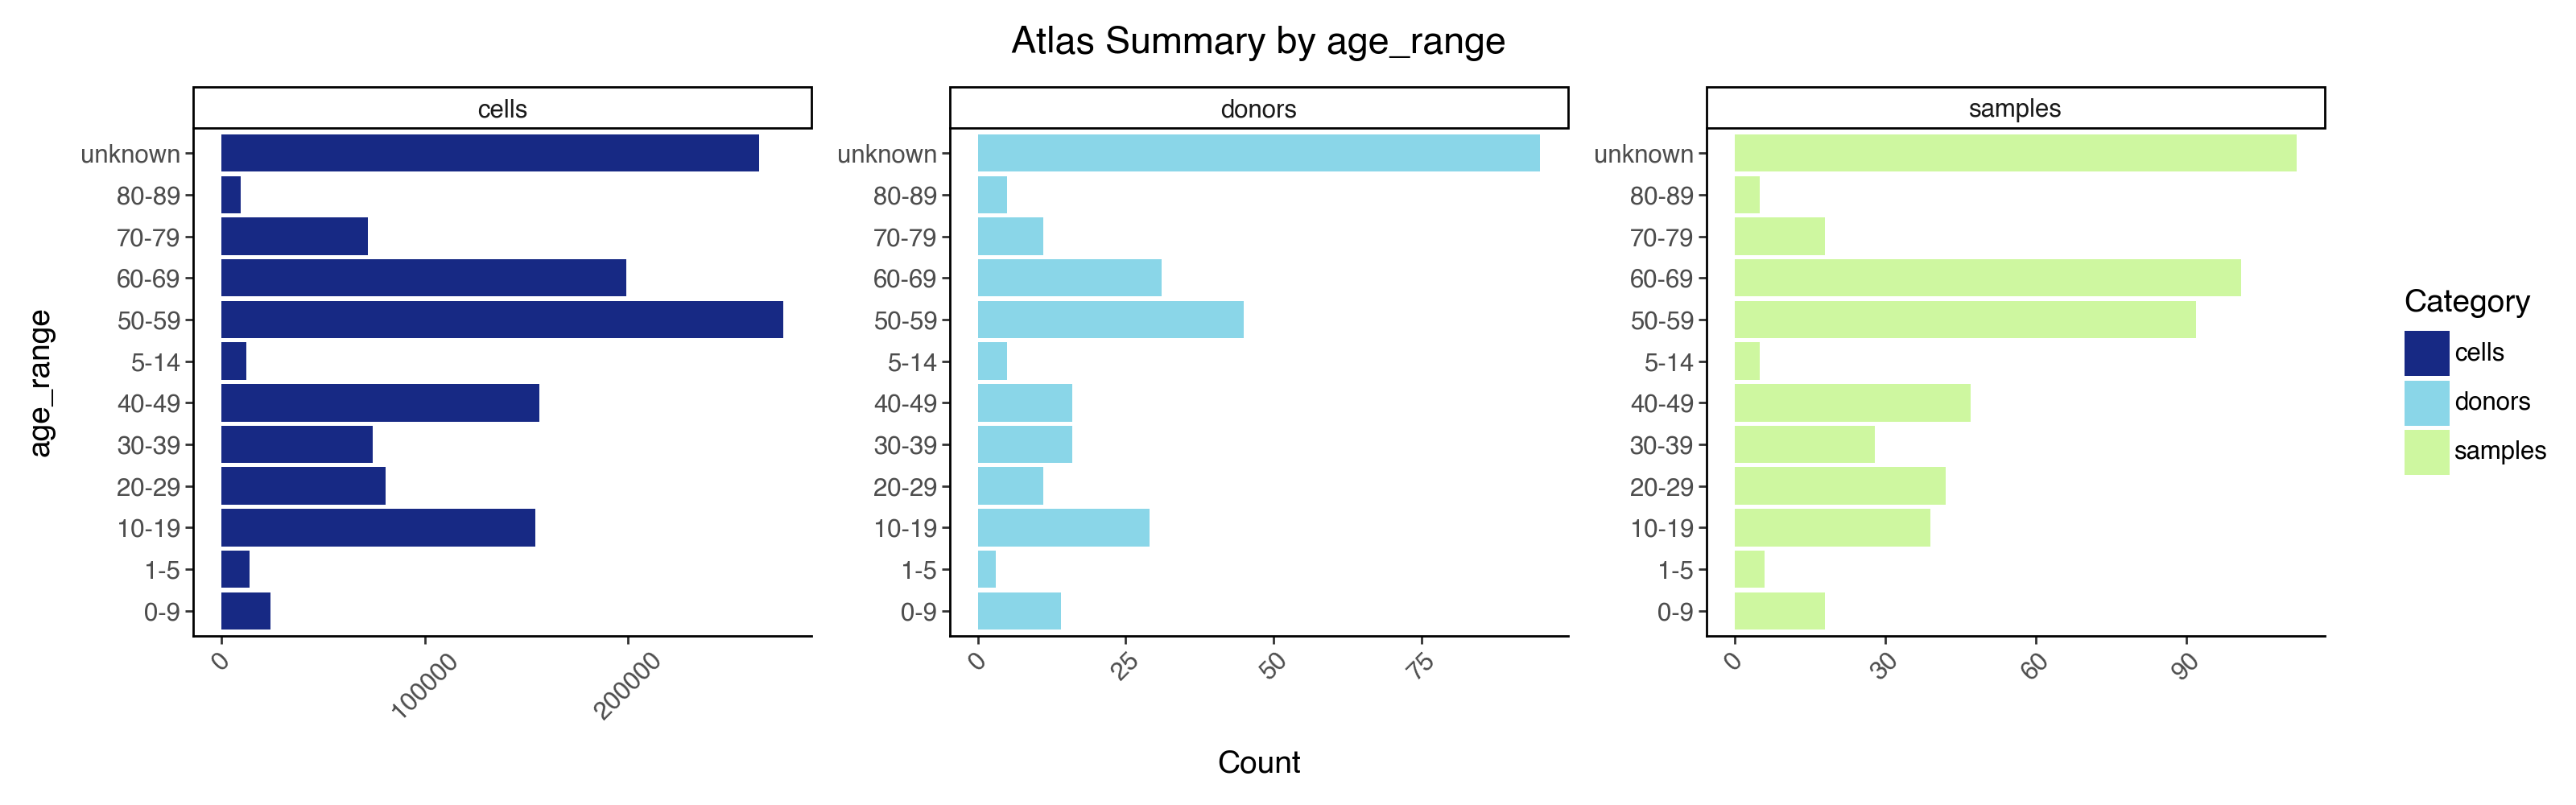

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/age_range_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [41]:
group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"


# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [19]:
group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

pal = [
    # Blue/Turquoise Tones - small intestine
    '#8AD6E8', '#1D7874', '#172984', '#34C0C0',
    # Red/Pink/Orange Tones - large intestine
    '#E56399', '#F45B69', '#DA4167', '#EDC7CF', '#F08700', '#D17B0F', '#CEF7A0',
    # Neutral/Grey - mesentery
    '#5B6C5D'
]
tissue_order = reversed(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)




## See bottom of notebook for best age-range/tissue section plots

In [42]:
############

from plotnine import (
    ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, 
    element_text, theme, scale_fill_manual, labs
)

# special function for ordered, grouped colors

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None):
    # Ensure tissue_order is correctly set and matches the color palette length
    tissue_order = ['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                    'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
                    'rectum', 'gastrointestinal_system_mesentery']

    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=dict(zip(tissue_order, color_palette)))  # Assign colors explicitly
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    return p

# Example usage
plot = create_faceted_bar_graph(meta, 'age_range', pal, 'tissue_ontology_term')
plot.draw(show=True)

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)

NameError: name 'pal' is not defined

In [21]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs, facet_grid

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Compute summary statistics per group
    if stacking_var:
        df[stacking_var] = df[stacking_var].astype(str)
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # melted_df[stacking_var] = pd.Categorical(melted_df[stacking_var], categories=stacking_values)

        # Add a new column to identify records that fall within the stacking_values or outside it
        # melted_df['Group'] = melted_df[stacking_var].apply(lambda x: 'Not in integration' if x in stacking_values else 'In integration')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits = stacking_values, breaks = stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p



/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_99330/2171250347.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


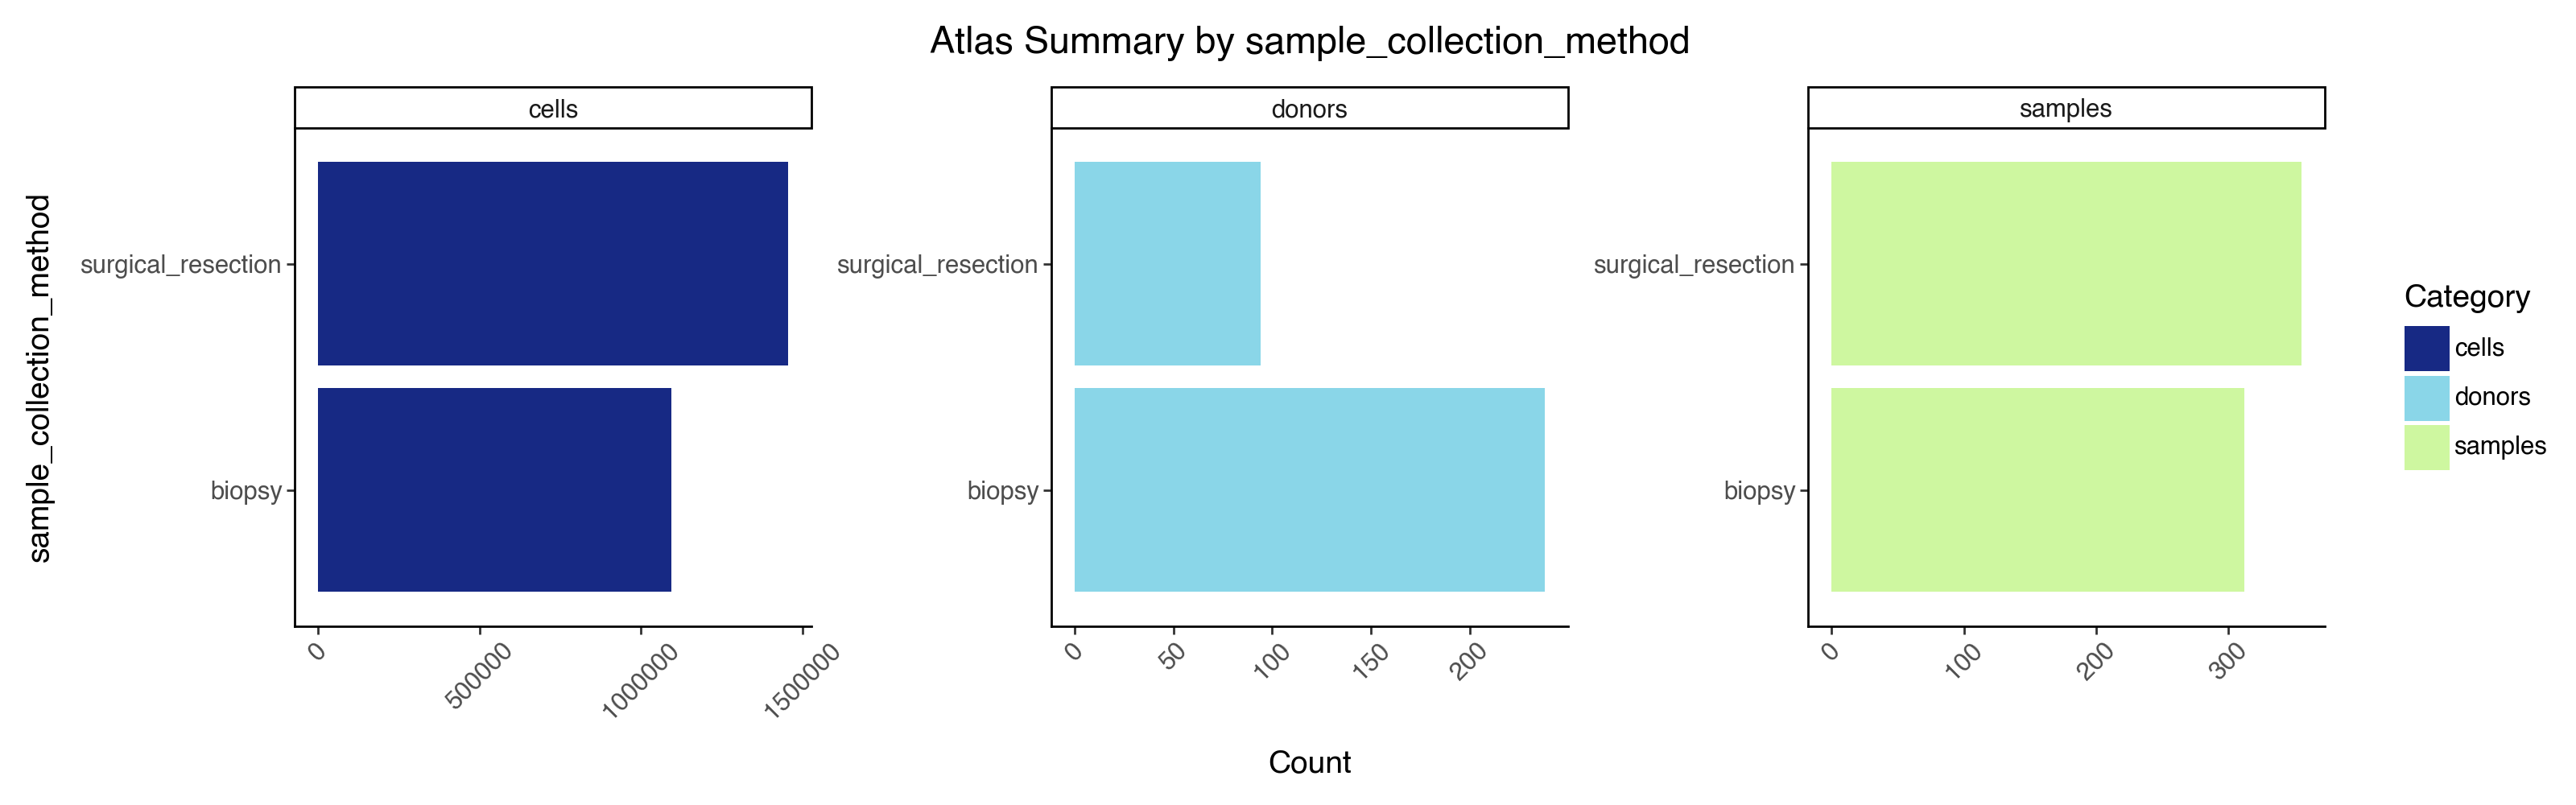

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sample_collection_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [22]:
group = 'sample_collection_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [23]:
meta['sampled_site_condition']

0           healthy
1           healthy
2           healthy
3           healthy
4           healthy
             ...   
3381934    adjacent
3381935    adjacent
3381936    adjacent
3381937    adjacent
3381938    adjacent
Name: sampled_site_condition, Length: 3381939, dtype: object

In [24]:
def adjust_condition(row):
    if row['sampled_site_condition'] == 'LP':
        return 'adjacent' if row['disease_free_text'] != 'Healthy' else 'Healthy'
    return row['sampled_site_condition']

meta['sampled_site_condition'] = meta.apply(adjust_condition, axis=1)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_99330/2527021510.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


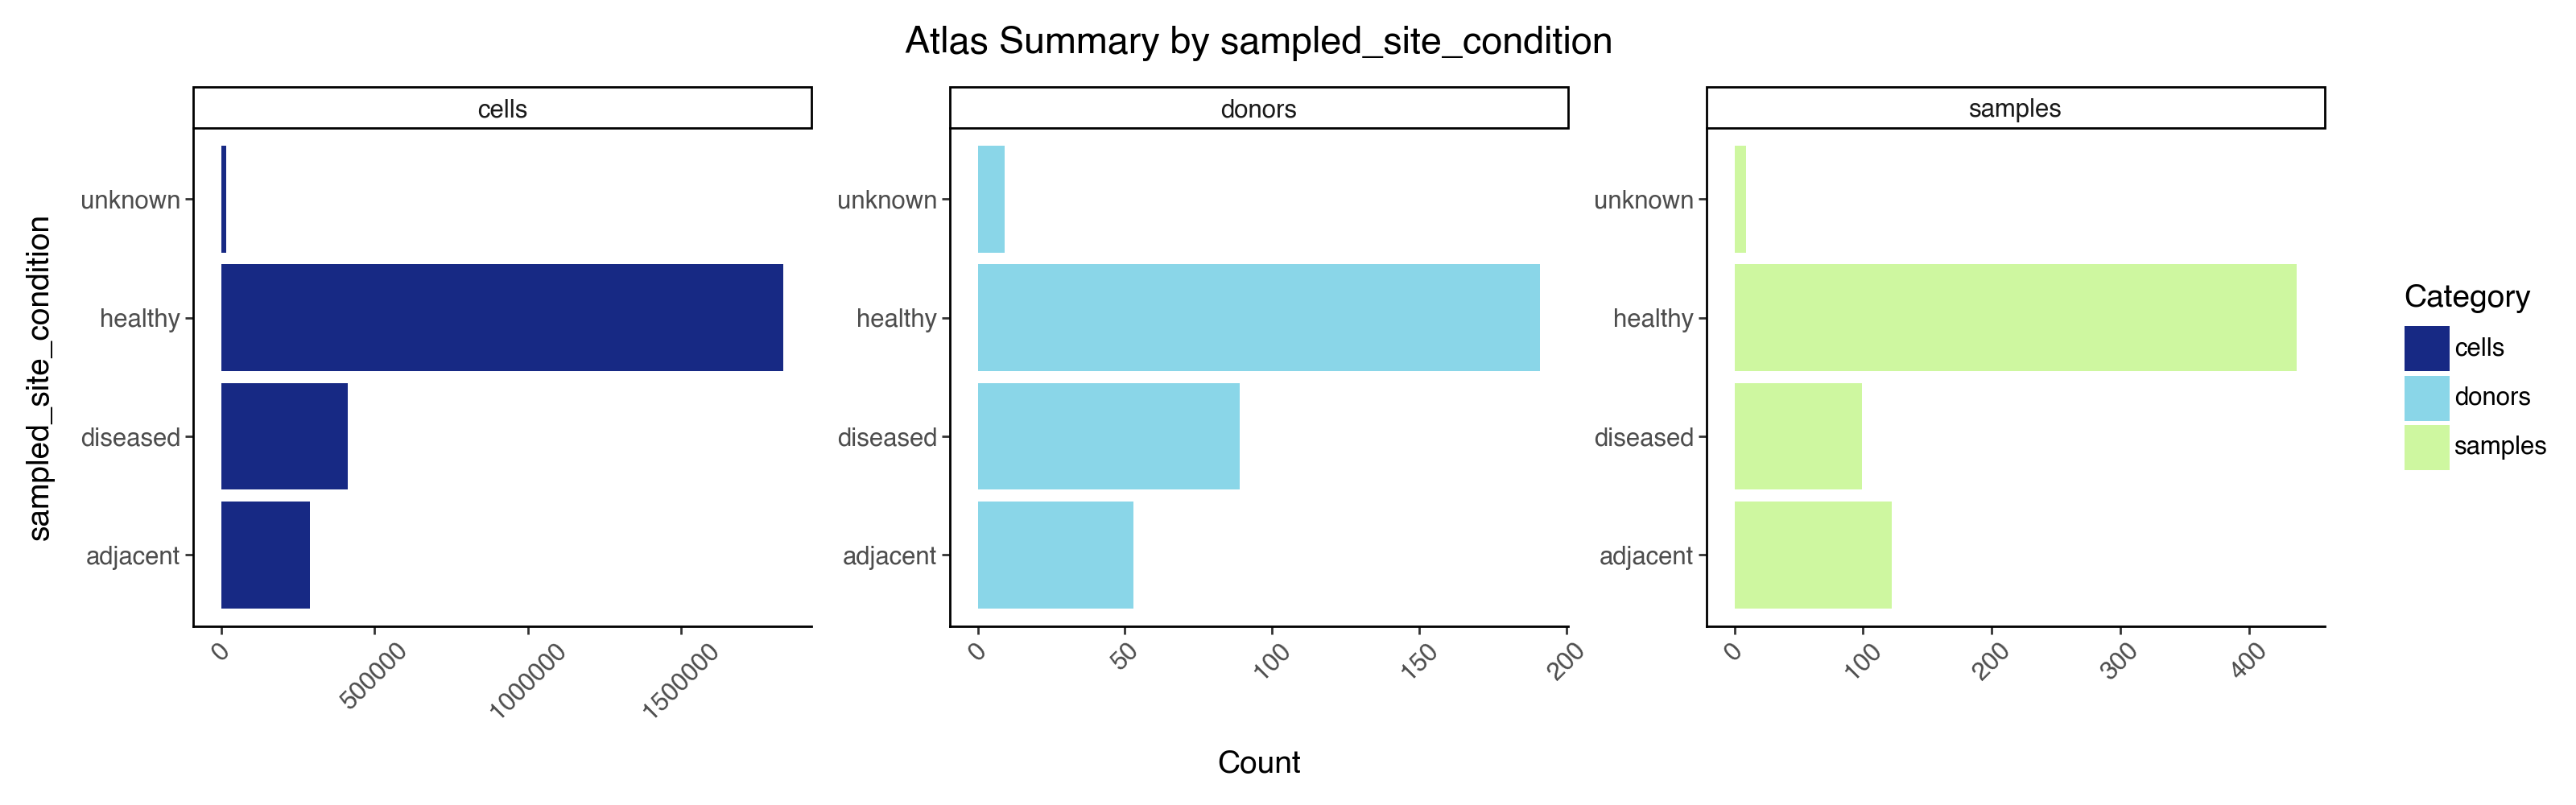

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sampled_site_condition_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [25]:
group = 'sampled_site_condition'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [26]:
group = 'disease_free_text'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 25
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


KeyError: 'disease_free_text'

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/668770496.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


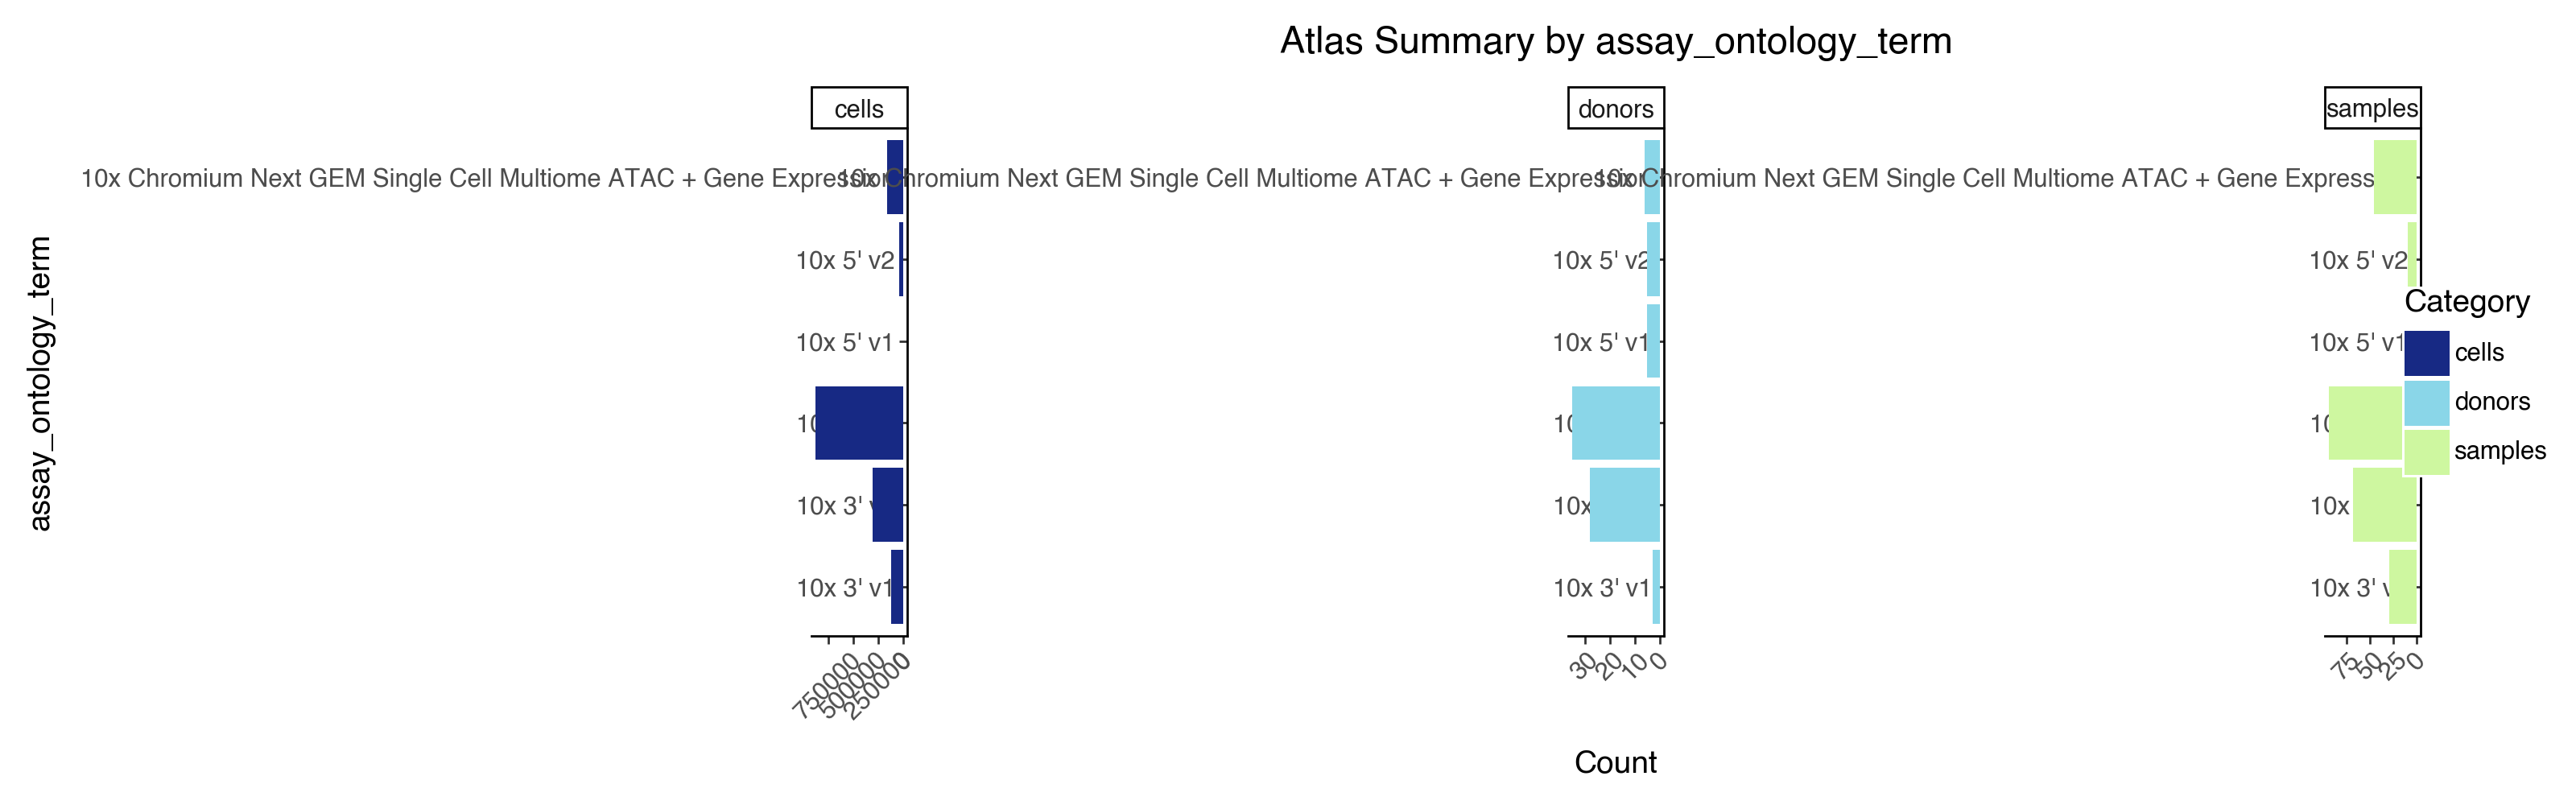

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/assay_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [58]:
group = 'assay_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_7714/1129336560.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


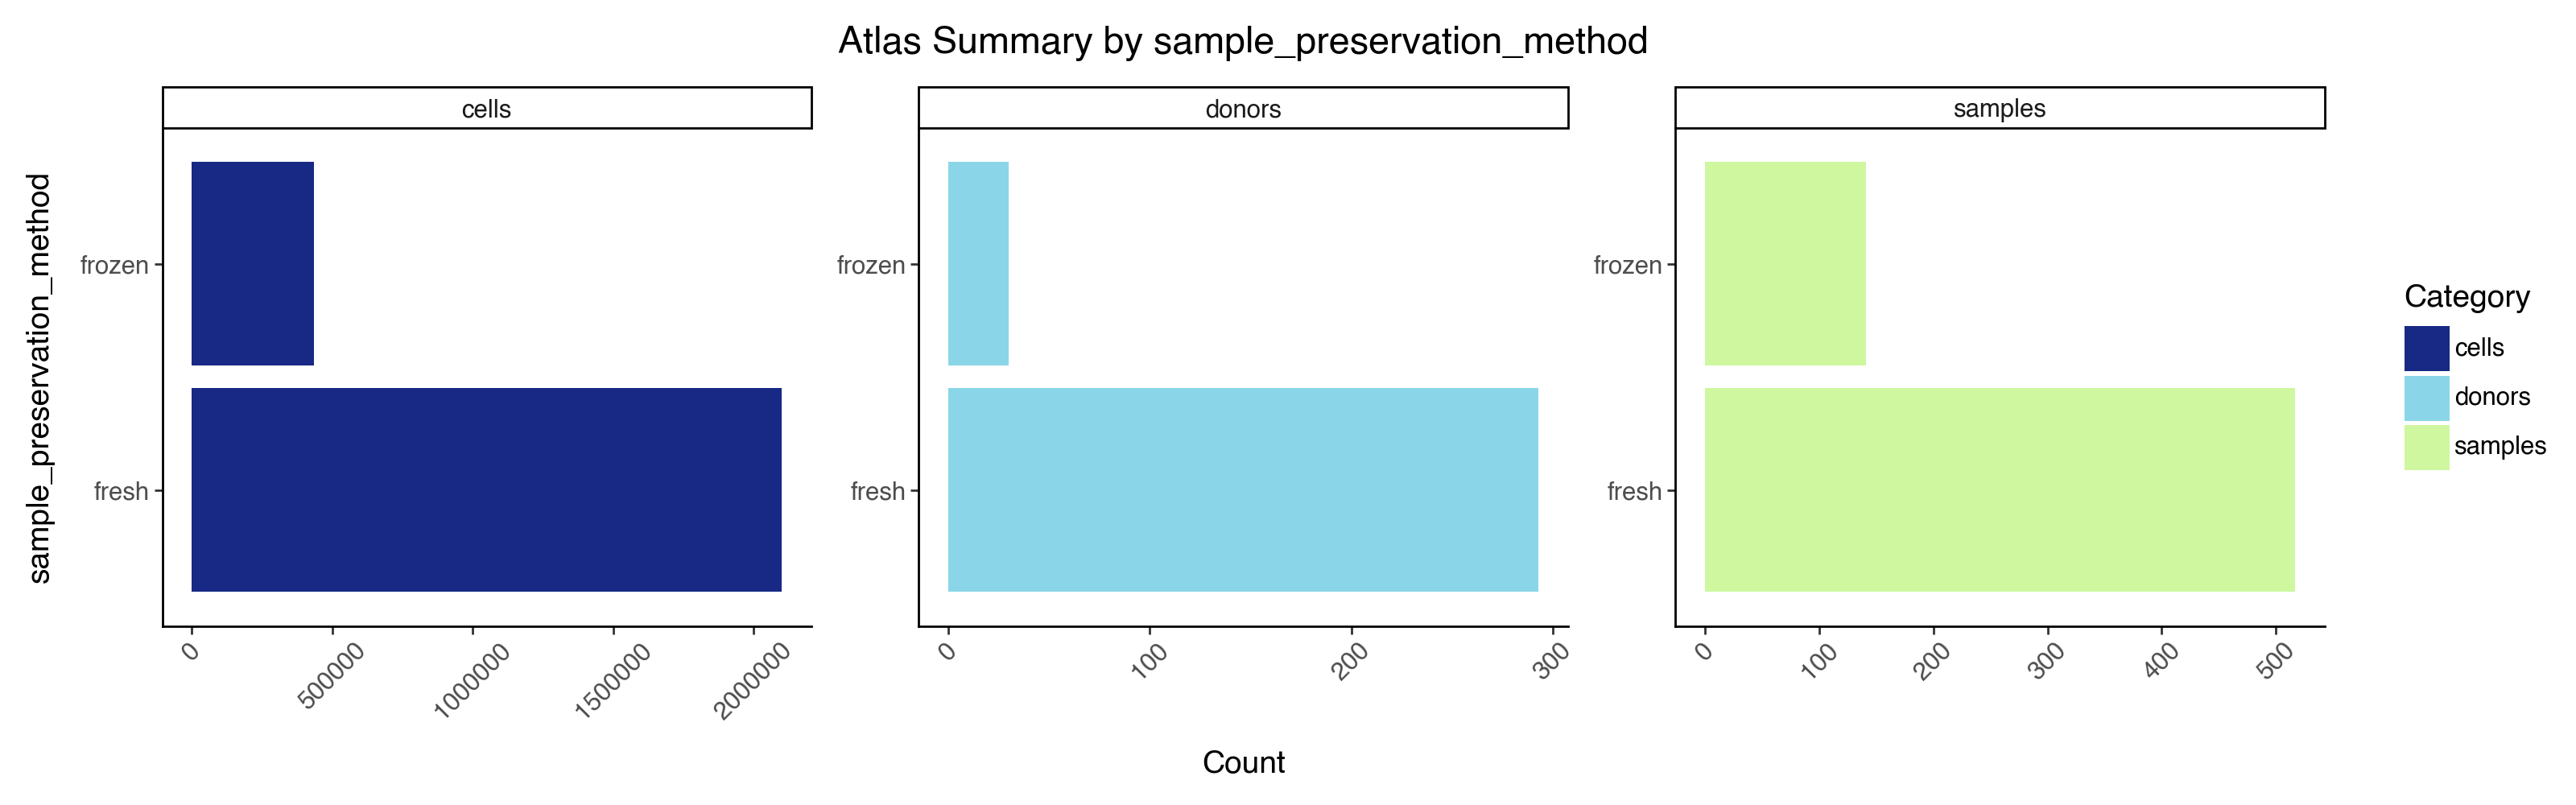

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/sample_preservation_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [59]:
group = 'sample_preservation_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [22]:
pal = [
    # Blue/Turquoise Tones - small intestine
    '#00A6D6',  # A stronger, more vivid blue
    '#1D4F91',  # Deep blue, less harsh than original
    '#27A0A3',  # Muted turquoise
    '#A8E6CF',  # Soft mint green for contrast
    '#00E6CF',  # straight up cyan
    
    # Red/Pink/Orange Tones - large intestine
    '#F8BBD0',  # Soft pink for lighter contrast
    '#E74C3C',  # Vivid red for emphasis
    '#F39C6B',  # Soft coral
    '#D1495B',  # Deep crimson for depth
    '#E27D60',  # Muted orange-pink
    '#F39C12',  # Warm orange, brighter but less harsh than #D17B0F

    # Neutral/Grey - mesentery
    '#666666',  # Medium grey, less harsh and easier on the eyes
]


# Correct ordering of tissue levels
tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)


In [23]:
def clean_age_ranges(age_range):
    # Randomly assign "5-15" to either "0-9" or "10-19"
    if age_range == "5-15":
        return np.random.choice(["0-9", "10-19"])
    if age_range == "5-14":
        return np.random.choice(["0-9", "10-19"])
    # Assign other overlapping ranges to appropriate buckets
    elif age_range == "5-9":
        return "0-9"
    elif age_range == "10-14":
        return "10-19"
    elif age_range == "1-5":
        return "0-9"
    # Keep existing decade-wide ranges unchanged
    else:
        return age_range

# Apply the function to the 'age_range' column in meta
meta['age_range'] = meta['age_range'].apply(clean_age_ranges)


In [24]:
meta['age_range'] = meta['age_range'].astype(str)


In [25]:
meta['age_range'].value_counts()

age_range
50-59      235356
60-69      171873
40-49      118284
20-29      115811
70-79      100129
30-39       85749
10-19       54676
0-9         38514
unknown     30047
80-89        8850
Name: count, dtype: int64

In [26]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Convert stacking variable to categorical with a specific order
    if stacking_var:
        df[stacking_var] = pd.Categorical(df[stacking_var], categories=stacking_values, ordered=True)
        
        # Compute summary statistics per group
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits=stacking_values, breaks=stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p

group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_{group}_summary.png"

pal = [
    # Blue/Turquoise Tones - small intestine
    '#00A6D6',  # A stronger, more vivid blue
    '#1D4F91',  # Deep blue, less harsh than original
    '#27A0A3',  # Muted turquoise
    '#A8E6CF',  # Soft mint green for contrast
    '#00E6CF',  # straight up cyan
    
    # Red/Pink/Orange Tones - large intestine
    '#F8BBD0',  # Soft pink for lighter contrast
    '#E74C3C',  # Vivid red for emphasis
    '#F39C6B',  # Soft coral
    '#D1495B',  # Deep crimson for depth
    '#E27D60',  # Muted orange-pink
    '#F39C12',  # Warm orange, brighter but less harsh than #D17B0F

    # Neutral/Grey - mesentery
    '#666666',  # Medium grey, less harsh and easier on the eyes
]




In [27]:
meta[['dataset_id','age_range']].drop_duplicates()

,dataset_id,age_range
CellID,,
BasuGCARNA_HA01AC_AAACCCAAGTCGGGAT-1,BasuGCARNA,50-59
BasuGCARNA_HA07AC_AAACCCAAGATCACCT-1,BasuGCARNA,70-79
BasuGCARNA_HA11AC_AAACCCAGTCACGCTG-1,BasuGCARNA,60-69
BasuGCARNA_HA50AC_AAACCCAGTGAGACGT-1,BasuGCARNA,40-49
BasuGCARNA_HA55AC_AAACCCAAGAGGTATT-1,BasuGCARNA,30-39
...,...,...
Egozi2023_AATGCCAGTACGTTCA-1,Egozi2023,0-9
Huang2019_AAAGATGTCAGTTGAC-GSM3584932,Huang2019,0-9
Elmentaite2020_AAATGCCAGTCCGGTC-WTDAtest7844020,Elmentaite2020,50-59


In [28]:
meta

,sample_id,author_cell_type,doublet_score,annotation_cluster,predicted_doublet,leiden_lineage_l1,leiden_lineage_l2,qc_lineage,n_counts,n_genes,...,n_cells,dataset diversity,sample diversity,Comment,AI suggestion,AI comment,lineage,cluster_level_1,cluster_level_2,cell_id
CellID,,,,,,,,,,,,,,,,,,,,,
BasuGCARNA_HA01AC_AAACCCAAGTCGGGAT-1,HA01-AC,TA Secretory,0.070826,Epithelial_13_2,False,13,13_2,Epithelial,1368.209768,573,...,1574.0,0.800291,0.983968,"refine, mostly absortive progenitors","Proliferative Epithelial, Transiently Amplifyi...","Cycling/TA markers: MKI67, TOP2A, UBE2C",Epithelial,Epithelial_13,Epithelial_13_2,BasuGCARNA_HA01AC_AAACCCAAGTCGGGAT-1
BasuGCARNA_HA01AC_AAACCCAAGTGAACAT-1,HA01-AC,EC,0.015908,Epithelial_0_0,False,0,0_0,Epithelial,901.165044,433,...,8342.0,0.626230,0.961127,crypt top markers,Colonocytes Late,crypt top markers | Absorptive mature markers:...,Epithelial,Epithelial_0,Epithelial_0_0,BasuGCARNA_HA01AC_AAACCCAAGTGAACAT-1
BasuGCARNA_HA01AC_AAACCCATCTACAGGT-1,HA01-AC,Colonocyte CEACAM-,0.019750,Epithelial_0_0,False,0,0_0,Epithelial,863.160018,356,...,8342.0,0.626230,0.961127,crypt top markers,Colonocytes Late,crypt top markers | Absorptive mature markers:...,Epithelial,Epithelial_0,Epithelial_0_0,BasuGCARNA_HA01AC_AAACCCATCTACAGGT-1
BasuGCARNA_HA01AC_AAACGAATCTGGCCTT-1,HA01-AC,Colonocyte progenitor,0.017747,Epithelial_10_1,False,10,10_1,Epithelial,769.357086,223,...,2017.0,0.767660,0.960714,NaN,Epithelial,NaN,Epithelial,Epithelial_10,Epithelial_10_1,BasuGCARNA_HA01AC_AAACGAATCTGGCCTT-1
BasuGCARNA_HA01AC_AAACGCTGTTCGTACA-1,HA01-AC,Colonocyte progenitor,0.014215,Epithelial_0_1,False,0,0_1,Epithelial,851.112312,259,...,8064.0,0.688906,0.967556,high ribo -> early?,Colonocytes Early,high ribo -> early? | Weighted by Major type =...,Epithelial,Epithelial_0,Epithelial_0_1,BasuGCARNA_HA01AC_AAACGCTGTTCGTACA-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Luoma2020_TTTGTCAAGGTGATTA-1,NC6_CD45,unknown,0.024697,Lymphoid_0_1,False,0,0_1,Lymphoid,814.253964,238,...,24885.0,0.719894,0.982430,NaN,CD4 Naive,CD4/Th program: IL7R; Weighted by Major type = T,Lymphoid,Lymphoid_0,Lymphoid_0_1,Luoma2020_TTTGTCAAGGTGATTA-1
Luoma2020_TTTGTCAAGTCAATAG-1-1,NC6_CD45,unknown,0.051395,Lymphoid_3_0,False,3,3_0,Lymphoid,925.714708,264,...,21800.0,0.126773,0.698822,This looks like a malformed cluster or a datas...,doublet,qc_flag indicates doublet; Weighted by Major t...,Lymphoid,Lymphoid_3,Lymphoid_3_0,Luoma2020_TTTGTCAAGTCAATAG-1-1
Luoma2020_TTTGTCACAACACCTA-1,NC6_CD45,unknown,0.042017,Lymphoid_2_1,False,2,2_1,Lymphoid,531.240522,237,...,11488.0,0.703653,0.972087,NaN,Plasma Cells,"Plasma markers: JCHAIN, MZB1, XBP1; Weighted b...",Lymphoid,Lymphoid_2,Lymphoid_2_1,Luoma2020_TTTGTCACAACACCTA-1


In [29]:
meta['tissue_ontology_term'].value_counts()

tissue_ontology_term
ileum                                415442
jejunum                              193320
colon                                139192
ascending colon                       94105
gastrointestinal system mesentery     26120
transverse colon                      14797
sigmoid colon                         14310
duodenum                              12815
caecum                                12650
rectum                                12502
small intestine                        2712
descending colon                       2514
vermiform appendix                      706
Name: count, dtype: int64

In [30]:
meta['age_range'].value_counts()

age_range
50-59      235356
60-69      171873
40-49      118284
20-29      115811
70-79      100129
30-39       85749
10-19       54676
0-9         38514
unknown     30047
80-89        8850
Name: count, dtype: int64

In [31]:
meta['tissue_ontology_term'].value_counts()


tissue_ontology_term
ileum                                415442
jejunum                              193320
colon                                139192
ascending colon                       94105
gastrointestinal system mesentery     26120
transverse colon                      14797
sigmoid colon                         14310
duodenum                              12815
caecum                                12650
rectum                                12502
small intestine                        2712
descending colon                       2514
vermiform appendix                      706
Name: count, dtype: int64

In [36]:
!pip install matplotlib

<ggplot: (1600 x 500)>


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/January2025_meeting/plots/tissue_age_range_summary.png
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_s

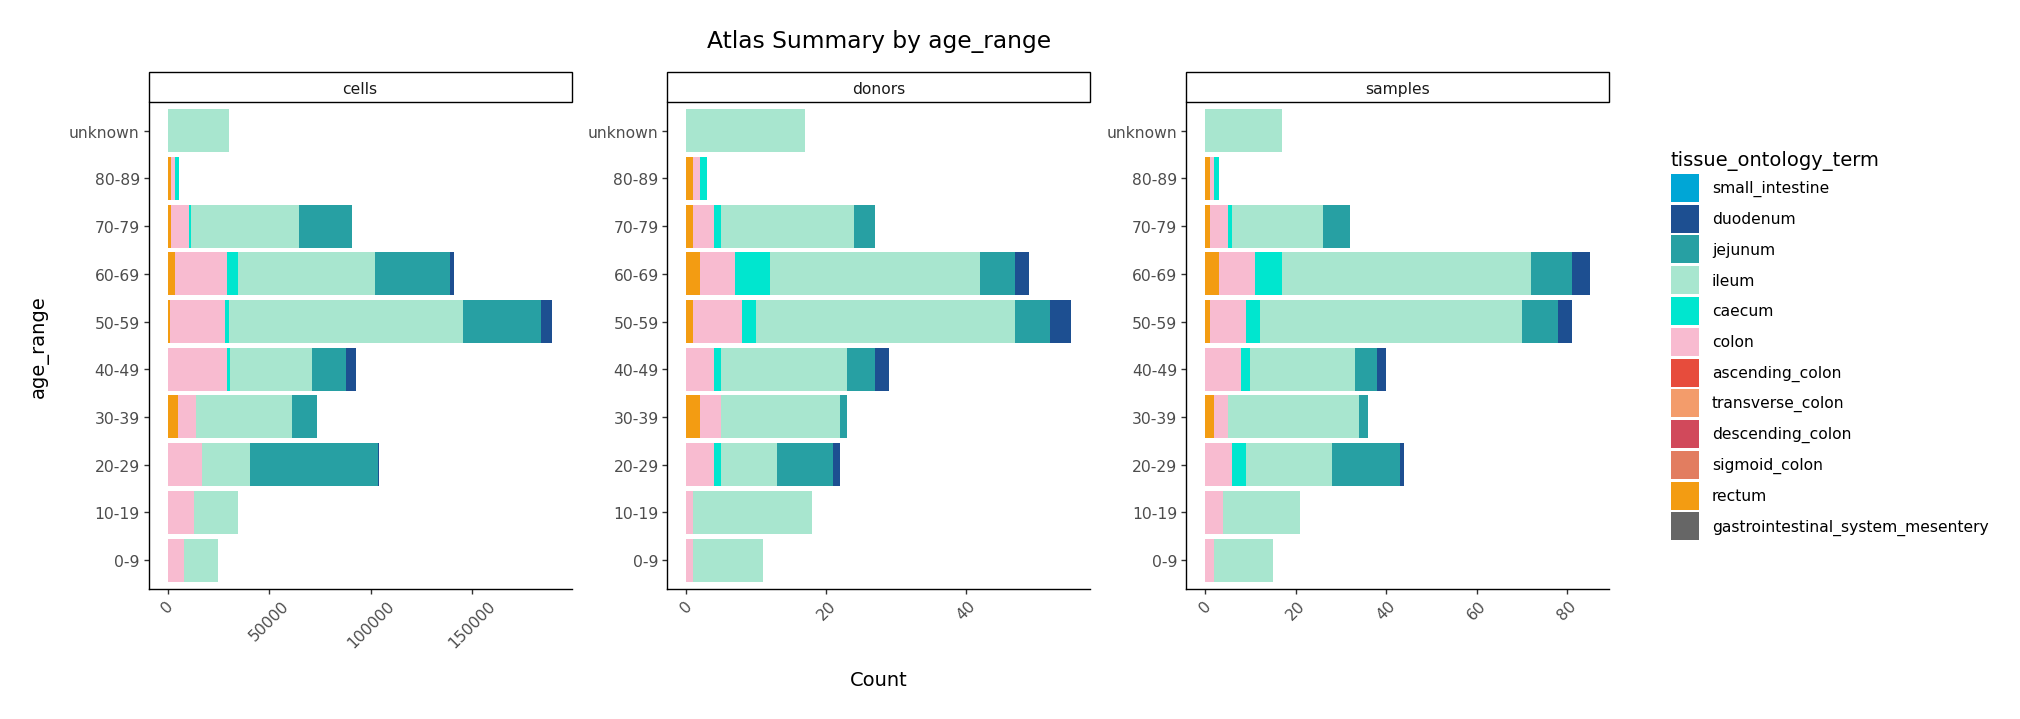

In [44]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from plotnine import *
import matplotlib

# Correct ordering of tissue levels
tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
                'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
               'rectum', 'gastrointestinal_system_mesentery'])

meta['tissue_ontology_term'] = meta['tissue_ontology_term'].str.replace('COLON', 'colon', case=False)

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var='age_range', 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)
plot = plot + theme(figure_size=(20, 7))
plot.draw()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/3609847814.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


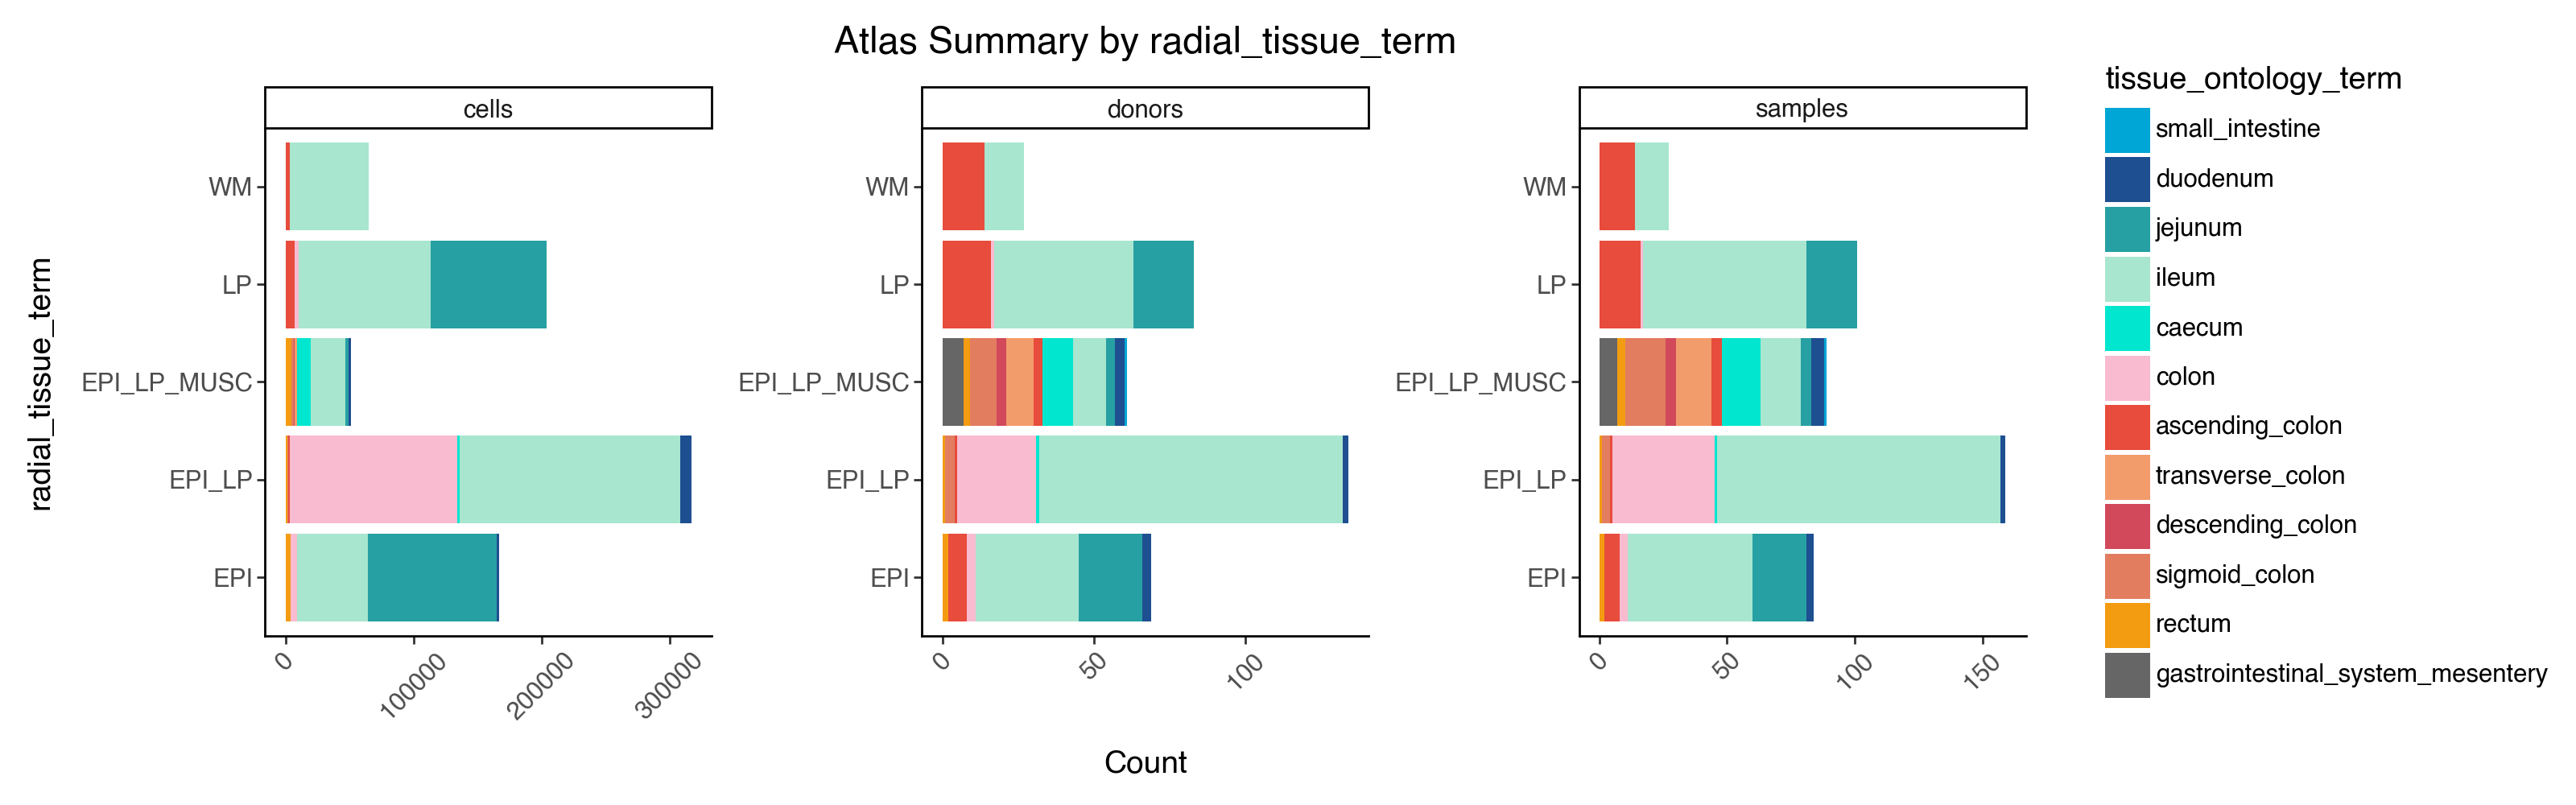

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_radial_tissue_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [30]:
group = 'radial_tissue_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [31]:
meta.columns

Index(['sample_id', 'author_cell_type', 'doublet_score', 'annotation_cluster',
       'predicted_doublet', 'leiden_lineage_l1', 'leiden_lineage_l2',
       'qc_lineage', 'n_counts', 'n_genes', 'closest_GCA_celltype_x',
       'cell_type_atlas', 'donor_id', 'dataset_id', 'tissue_ontology_term',
       'tissue_ontology_term_id', 'tissue_free_text', 'sample_source',
       'sample_collection_method', 'tissue_type', 'sampled_site_condition',
       'disease_ontology_term', 'disease_ontology_term_id',
       'sample_preservation_method', 'suspension_type', 'is_primary_data',
       'age_range', 'development_stage_ontology_term_id', 'radial_tissue_term',
       'dissociation_protocol', 'cell_enrichment', 'sample_collection_year',
       'library_id', 'library_id_repository', 'library_preparation_batch',
       'library_sequencing_run', 'sample_collection_site',
       'sample_collection_relative_time_point', 'cell_number_loaded',
       'cell_viability_percentage', 'institute', 'author_batch

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/3480270298.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


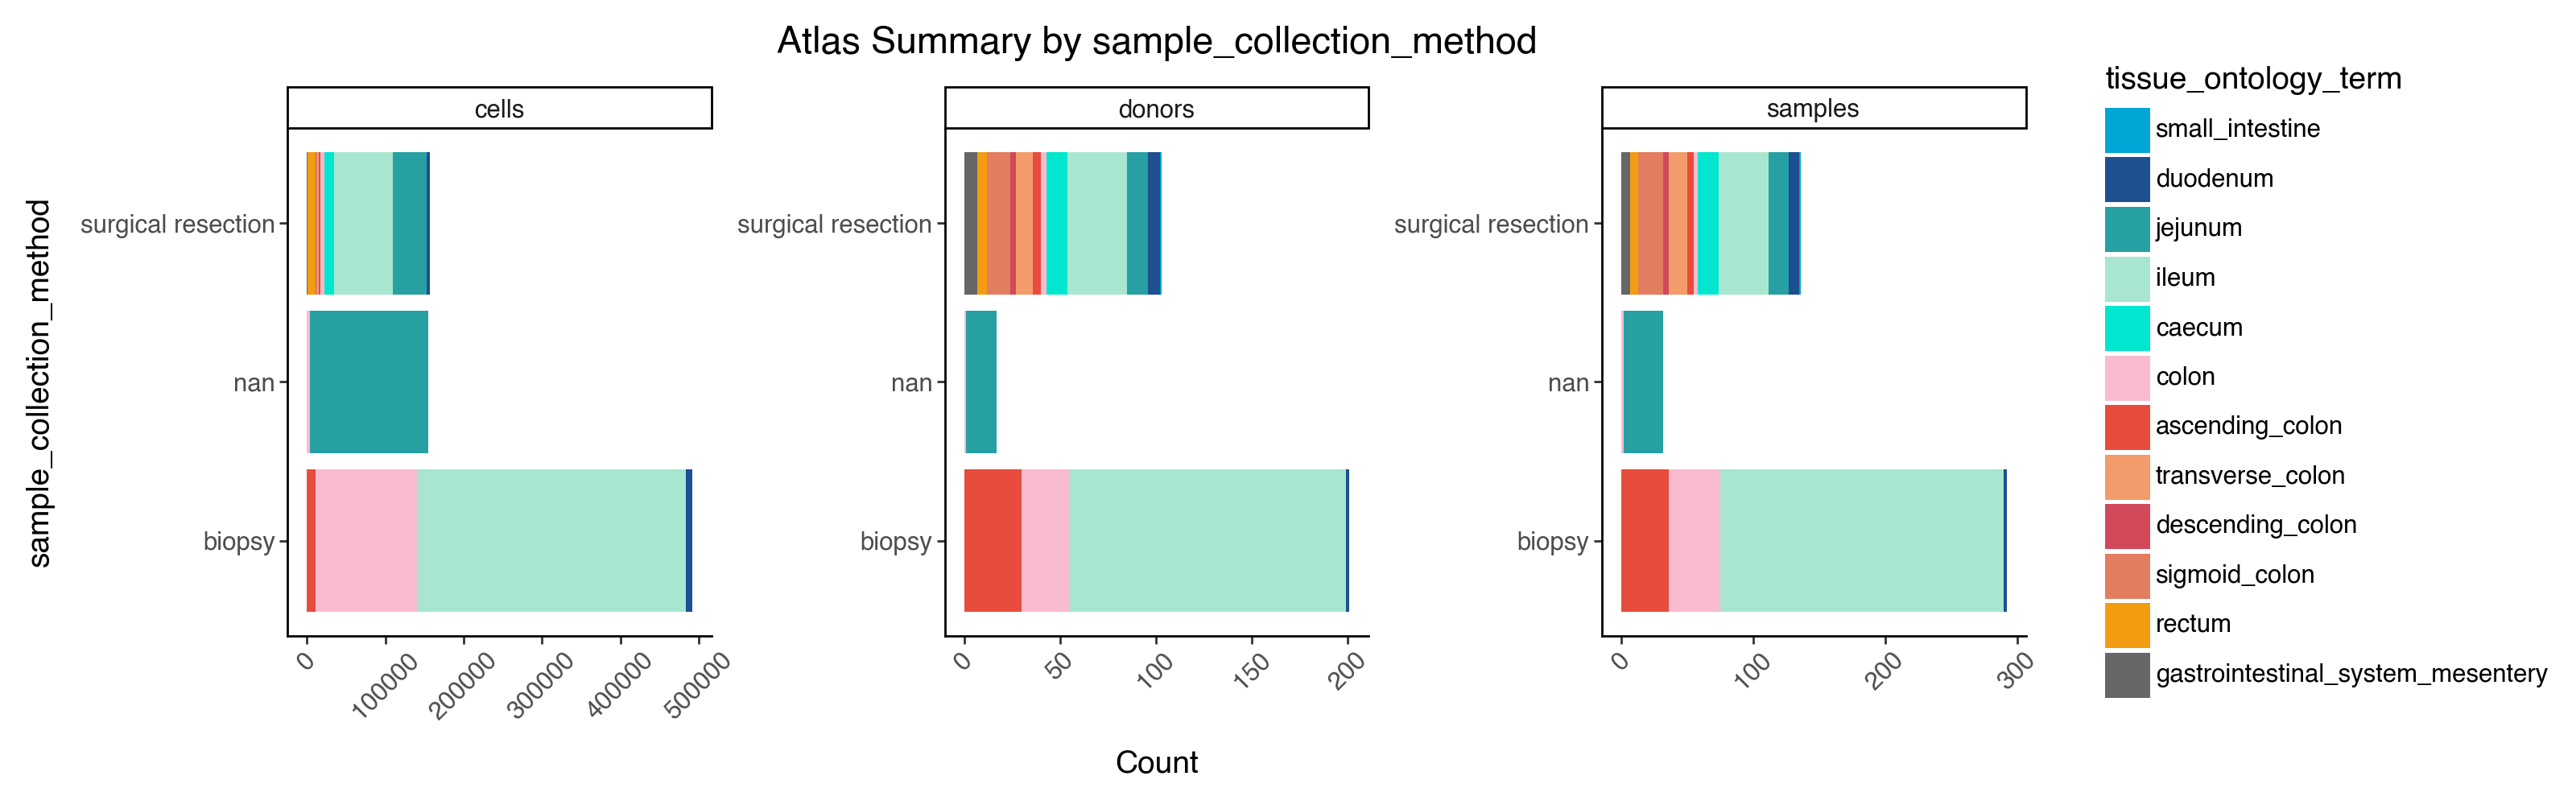

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_sample_collection_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [32]:
group = 'sample_collection_method'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/2374619873.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


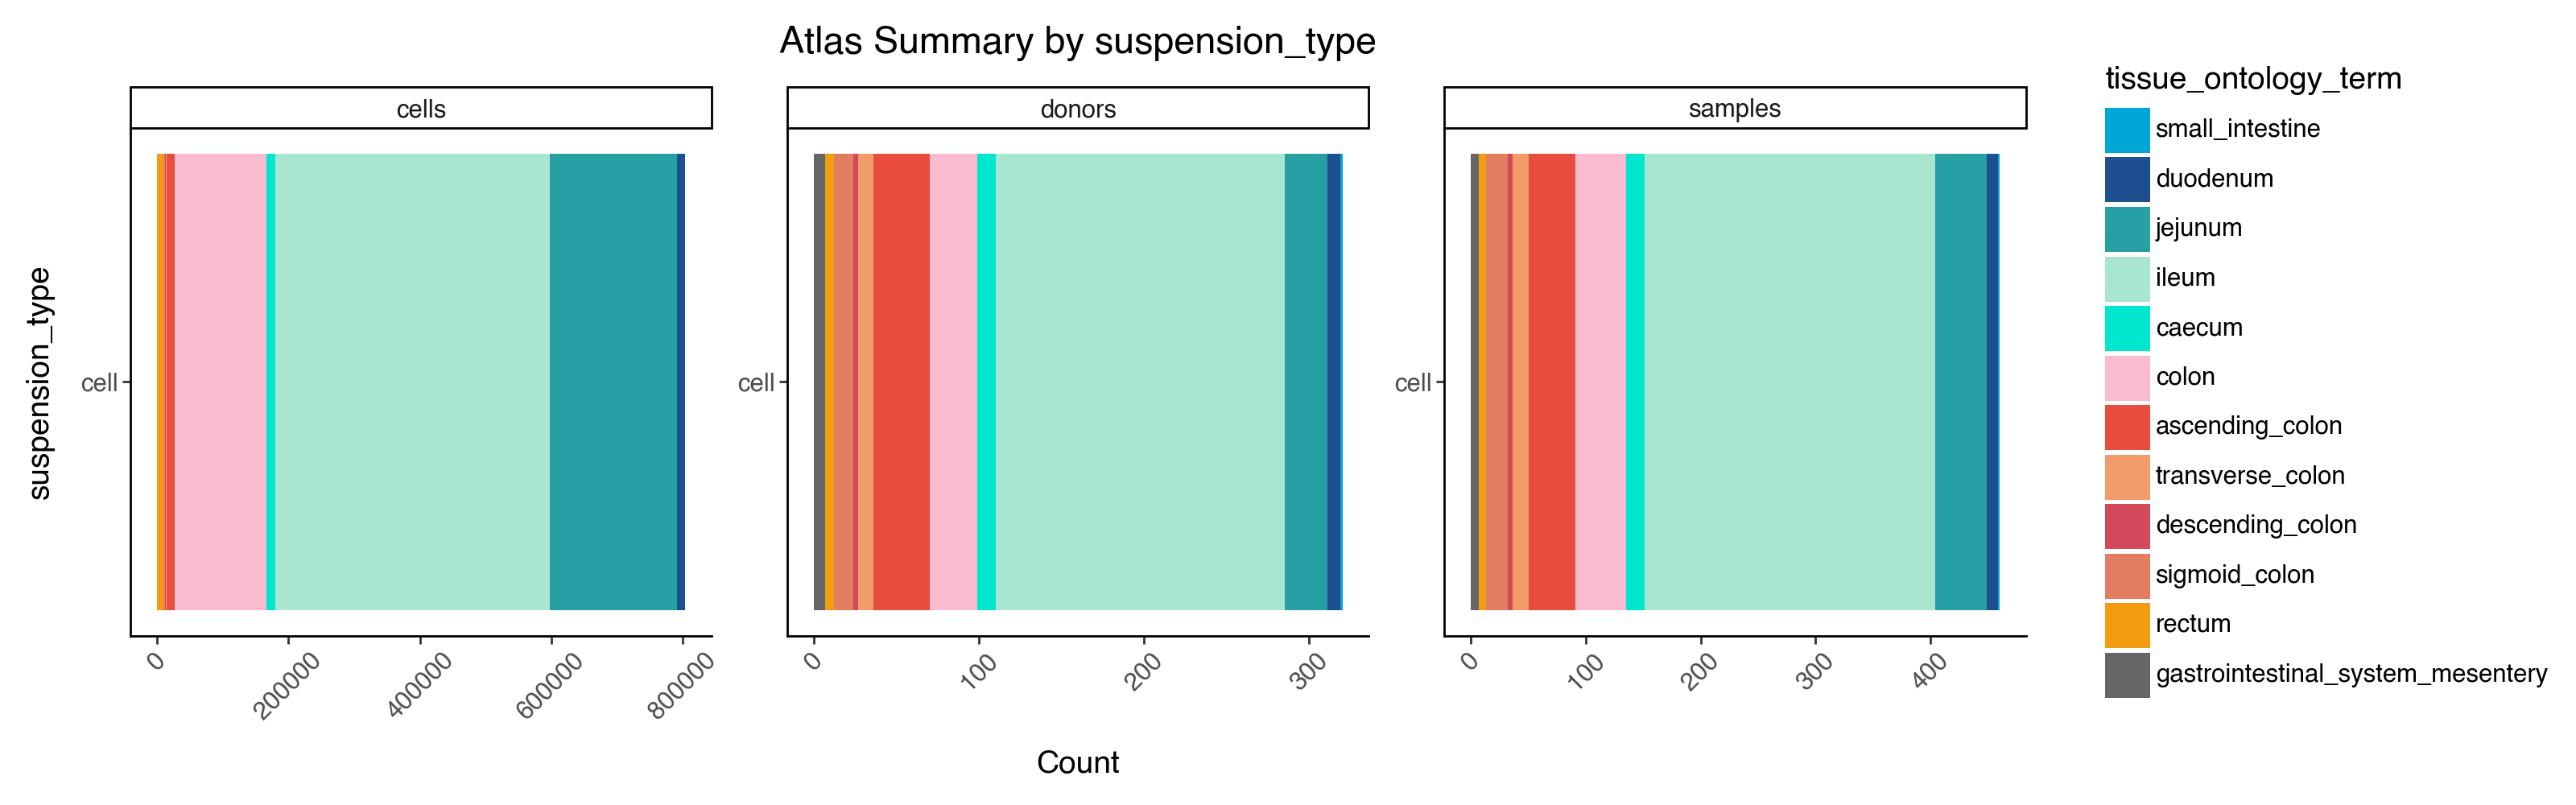

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_suspension_type_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [33]:
group = 'suspension_type'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [34]:
meta[['dataset_id','sampled_site_condition']].value_counts()

dataset_id           sampled_site_condition
Krzak2023            healthy                   115555
BasuGCARNA           healthy                   105253
Kong2023_v3          adjacent                   96648
Luoma2020            healthy                    64526
Elmentaite2020       healthy                    60009
KarakashevaHelmlsey  healthy                    50476
DominguezUnpub       healthy                    38095
James2020_3p         healthy                    28580
Huang2019            healthy                    20878
ArendsHelmsley       healthy                    20782
Martin2019           adjacent                   19930
Jaeger2021           adjacent                   19074
Zheng2024            healthy                    17864
Uzzan2022            healthy                    16512
Wang2020             adjacent                   15291
Luoma2020            adjacent                   15088
Lee2020              adjacent                   14524
Kong2023_v3          healthy          

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/769765780.py:13: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


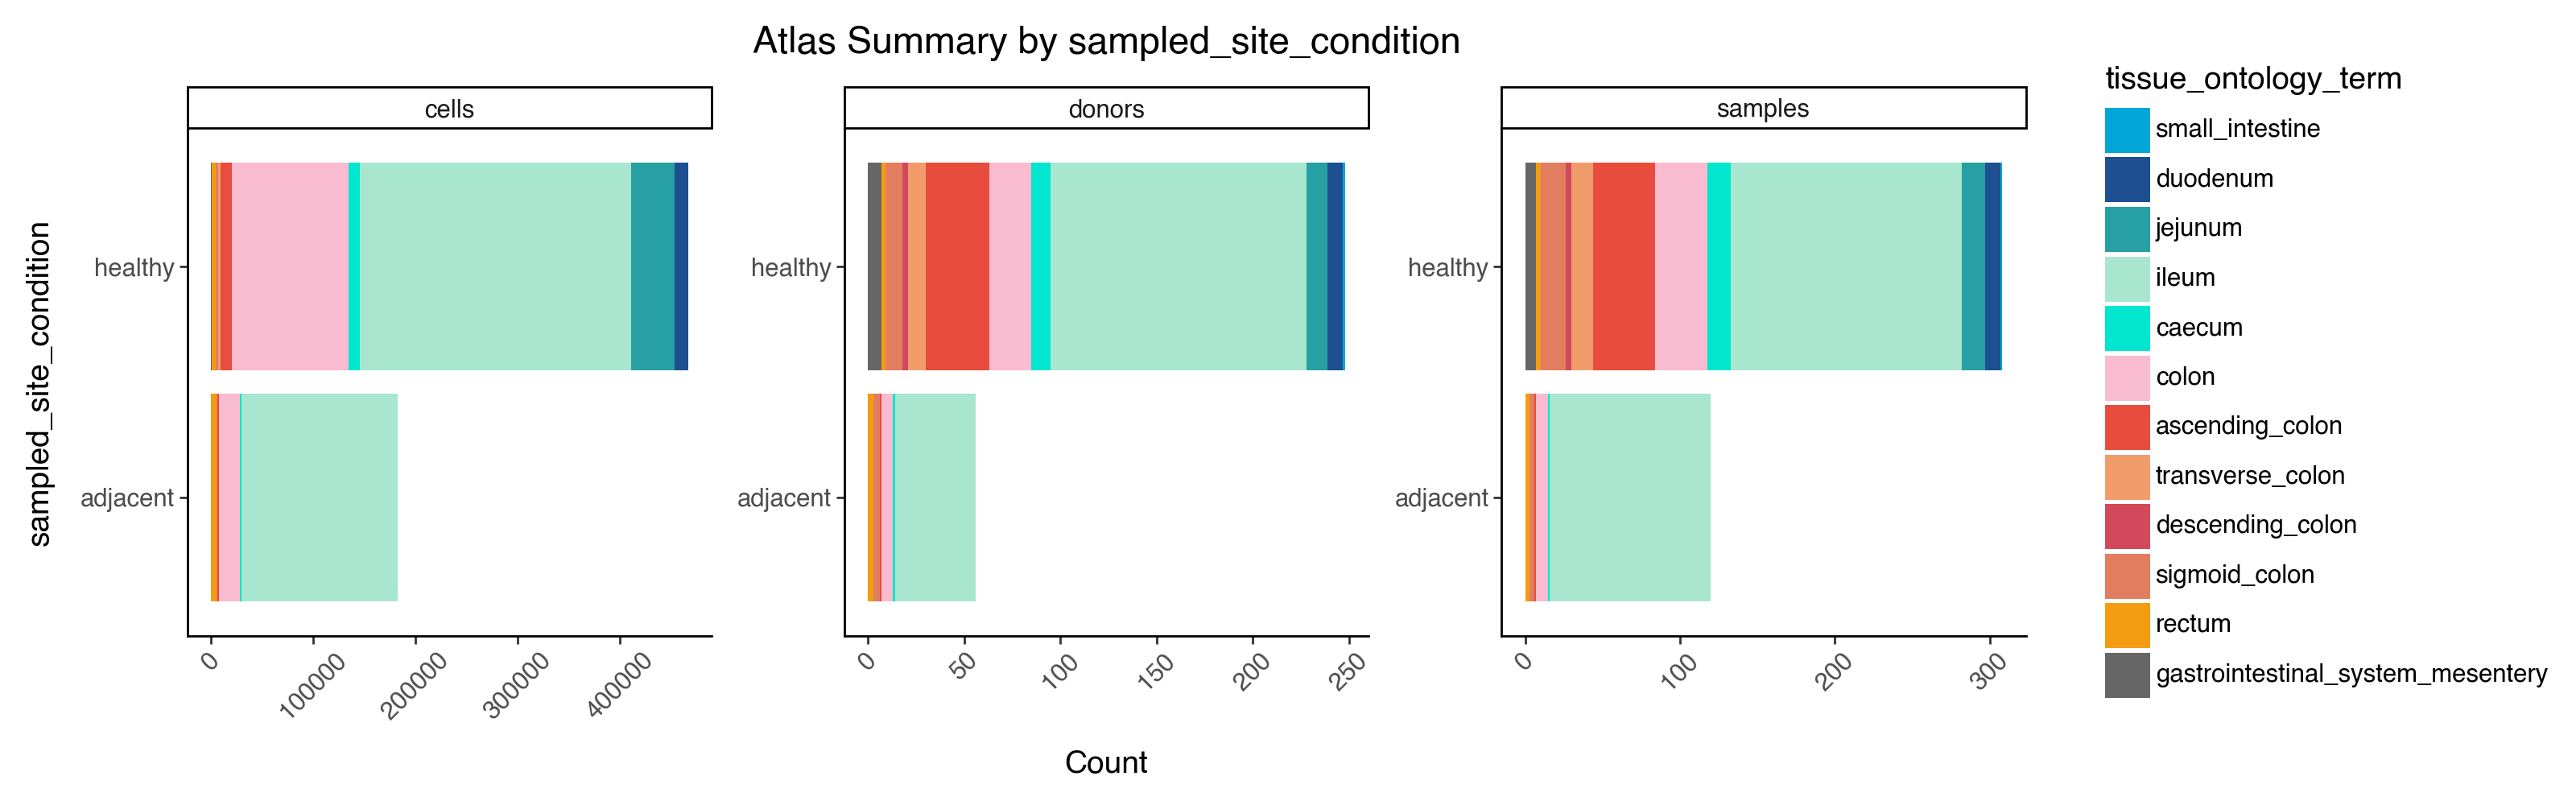

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_sampled_site_condition_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [35]:
group = 'sampled_site_condition'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/1551545406.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


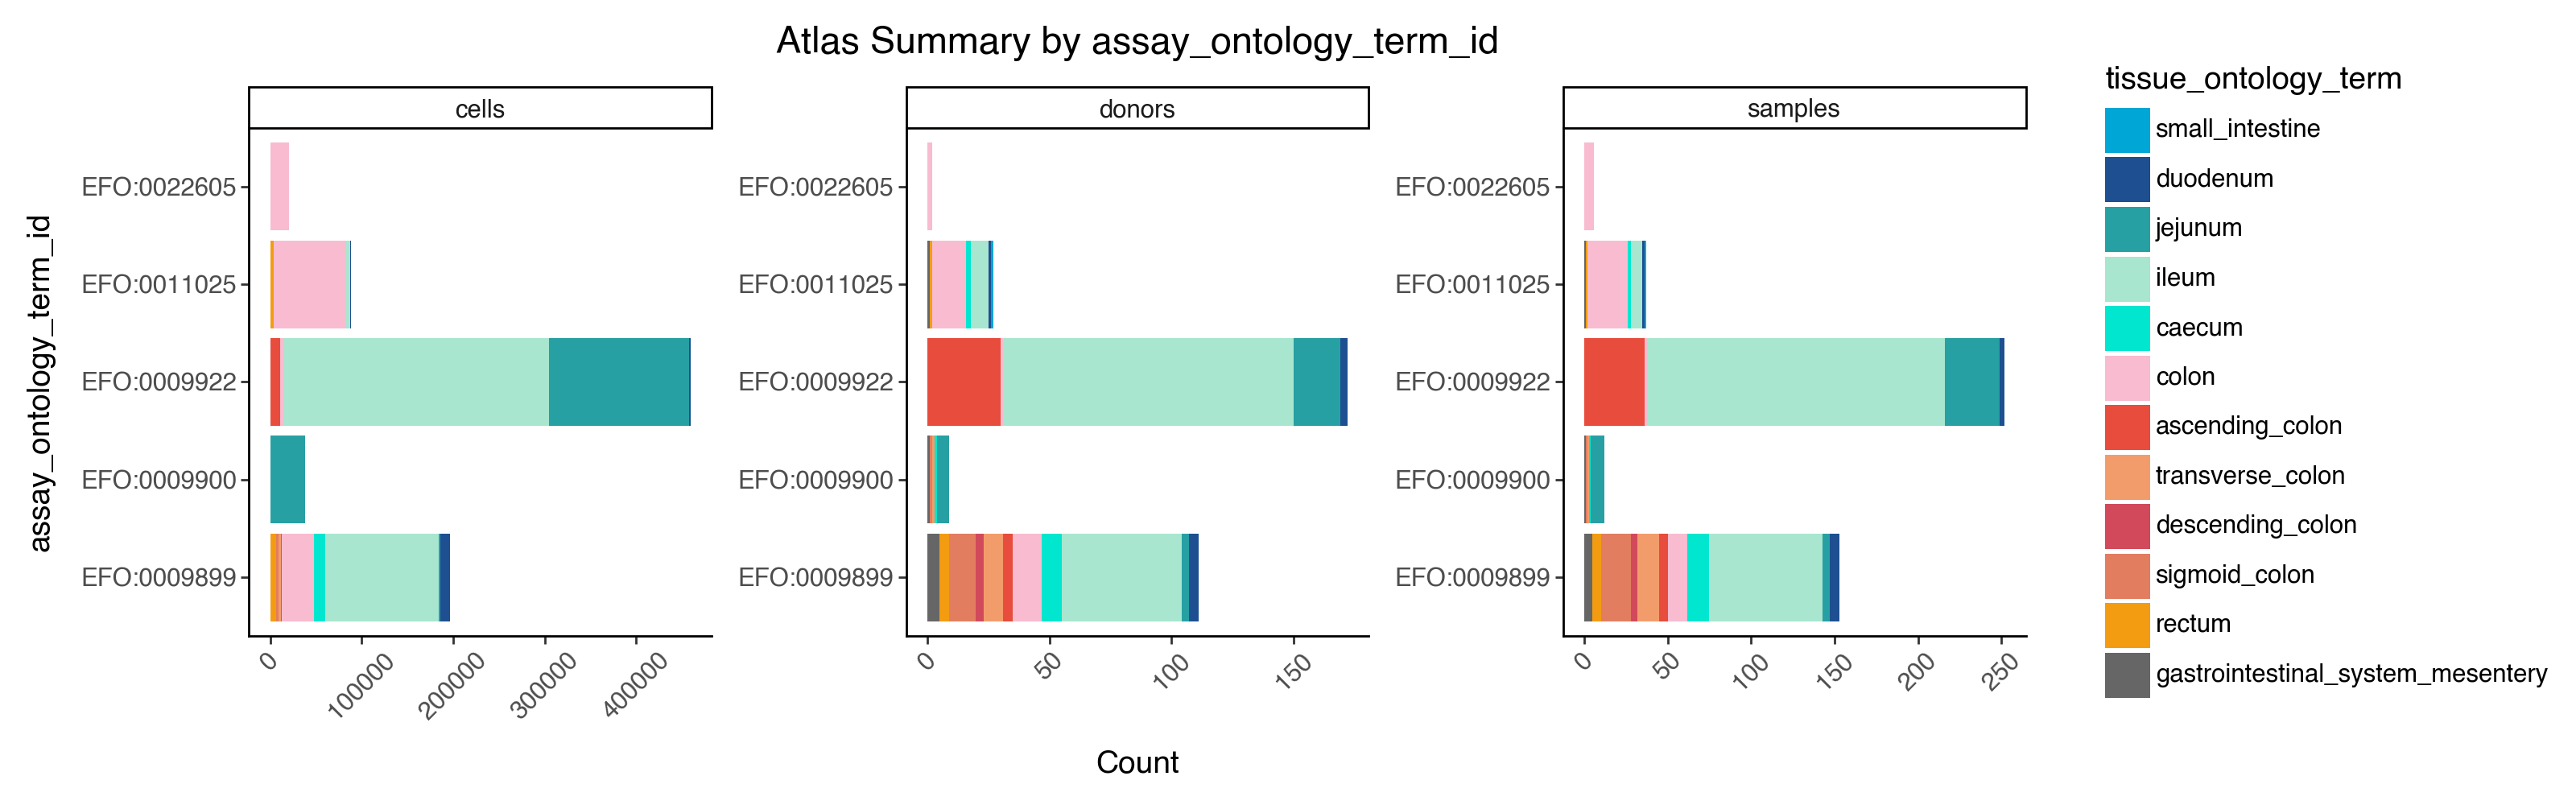

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_assay_ontology_term_id_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [40]:
# tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
#                 'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
#                'rectum', 'gastrointestinal_system_mesentery'])

group = 'assay_ontology_term_id'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_35378/2811239257.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


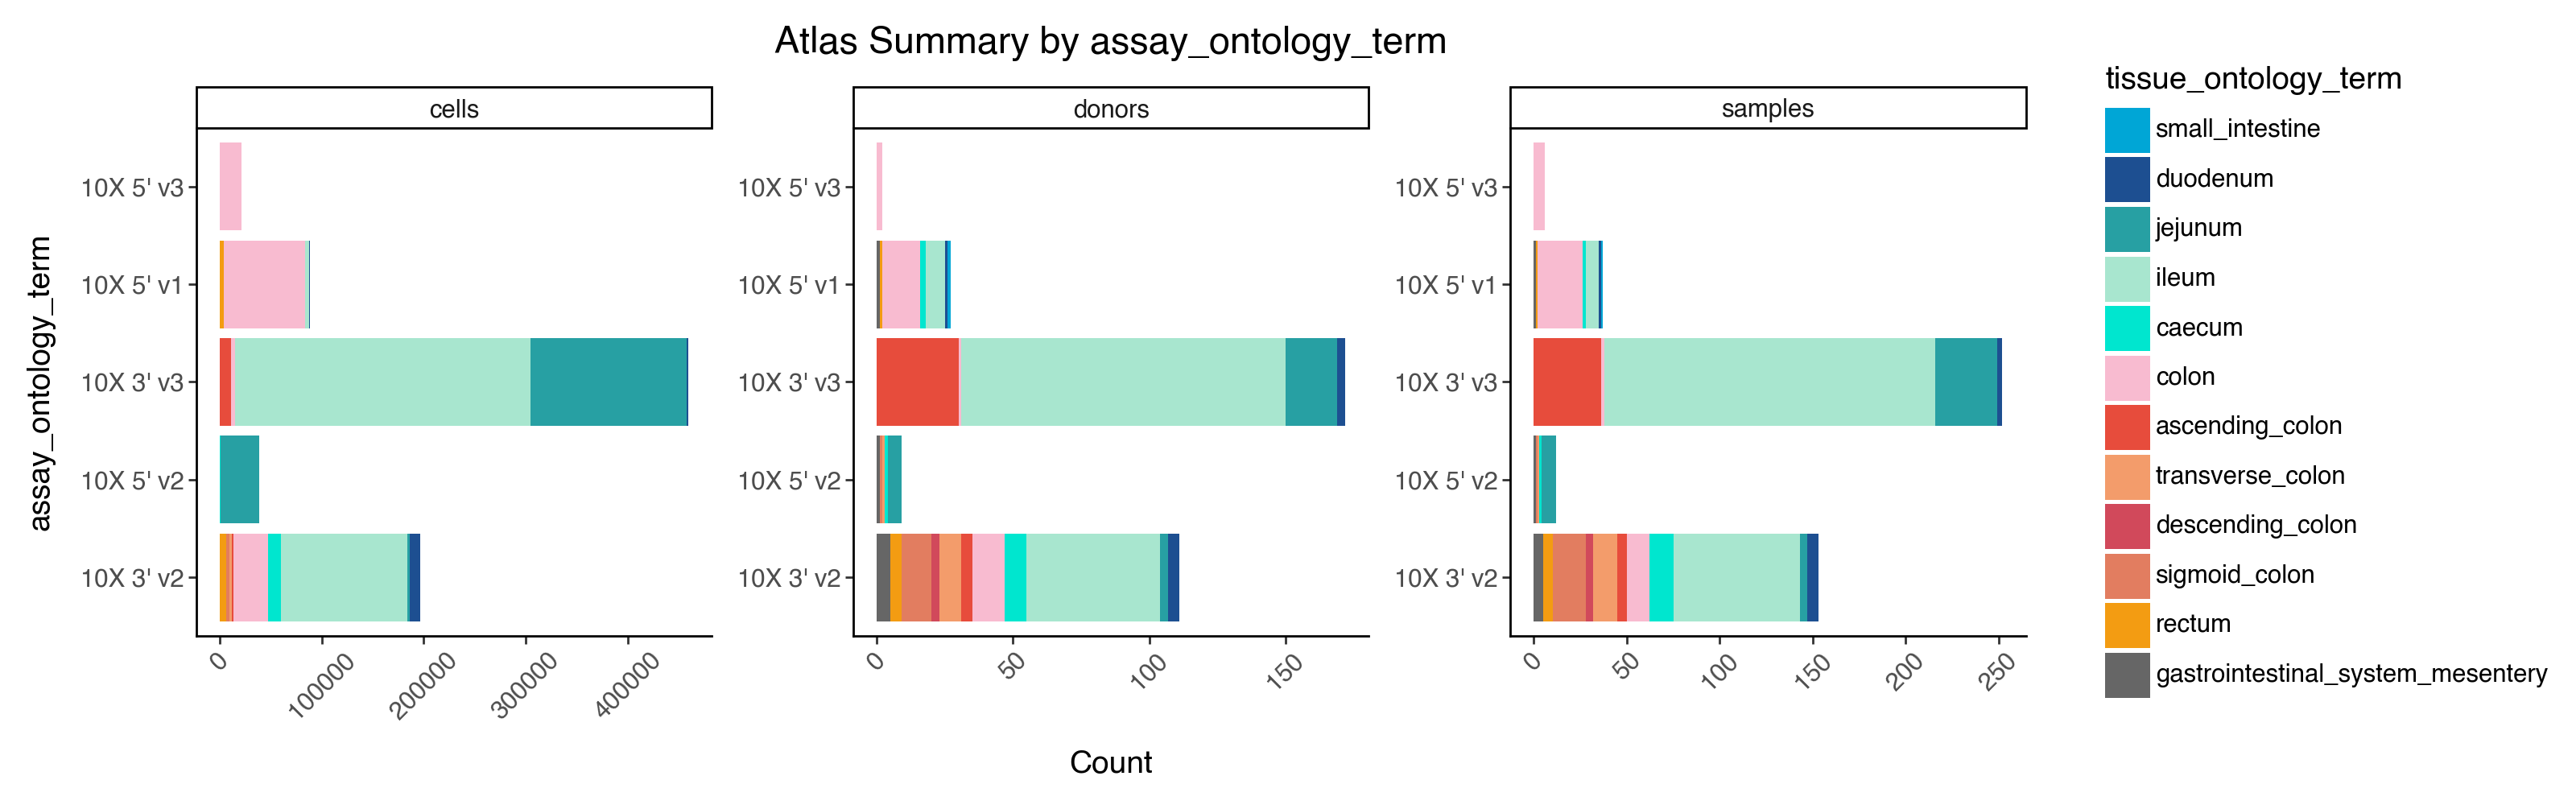

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_assay_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [41]:
# tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
#                 'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
#                'rectum', 'gastrointestinal_system_mesentery'])

group = 'assay_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_90378/2762301790.py:17: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


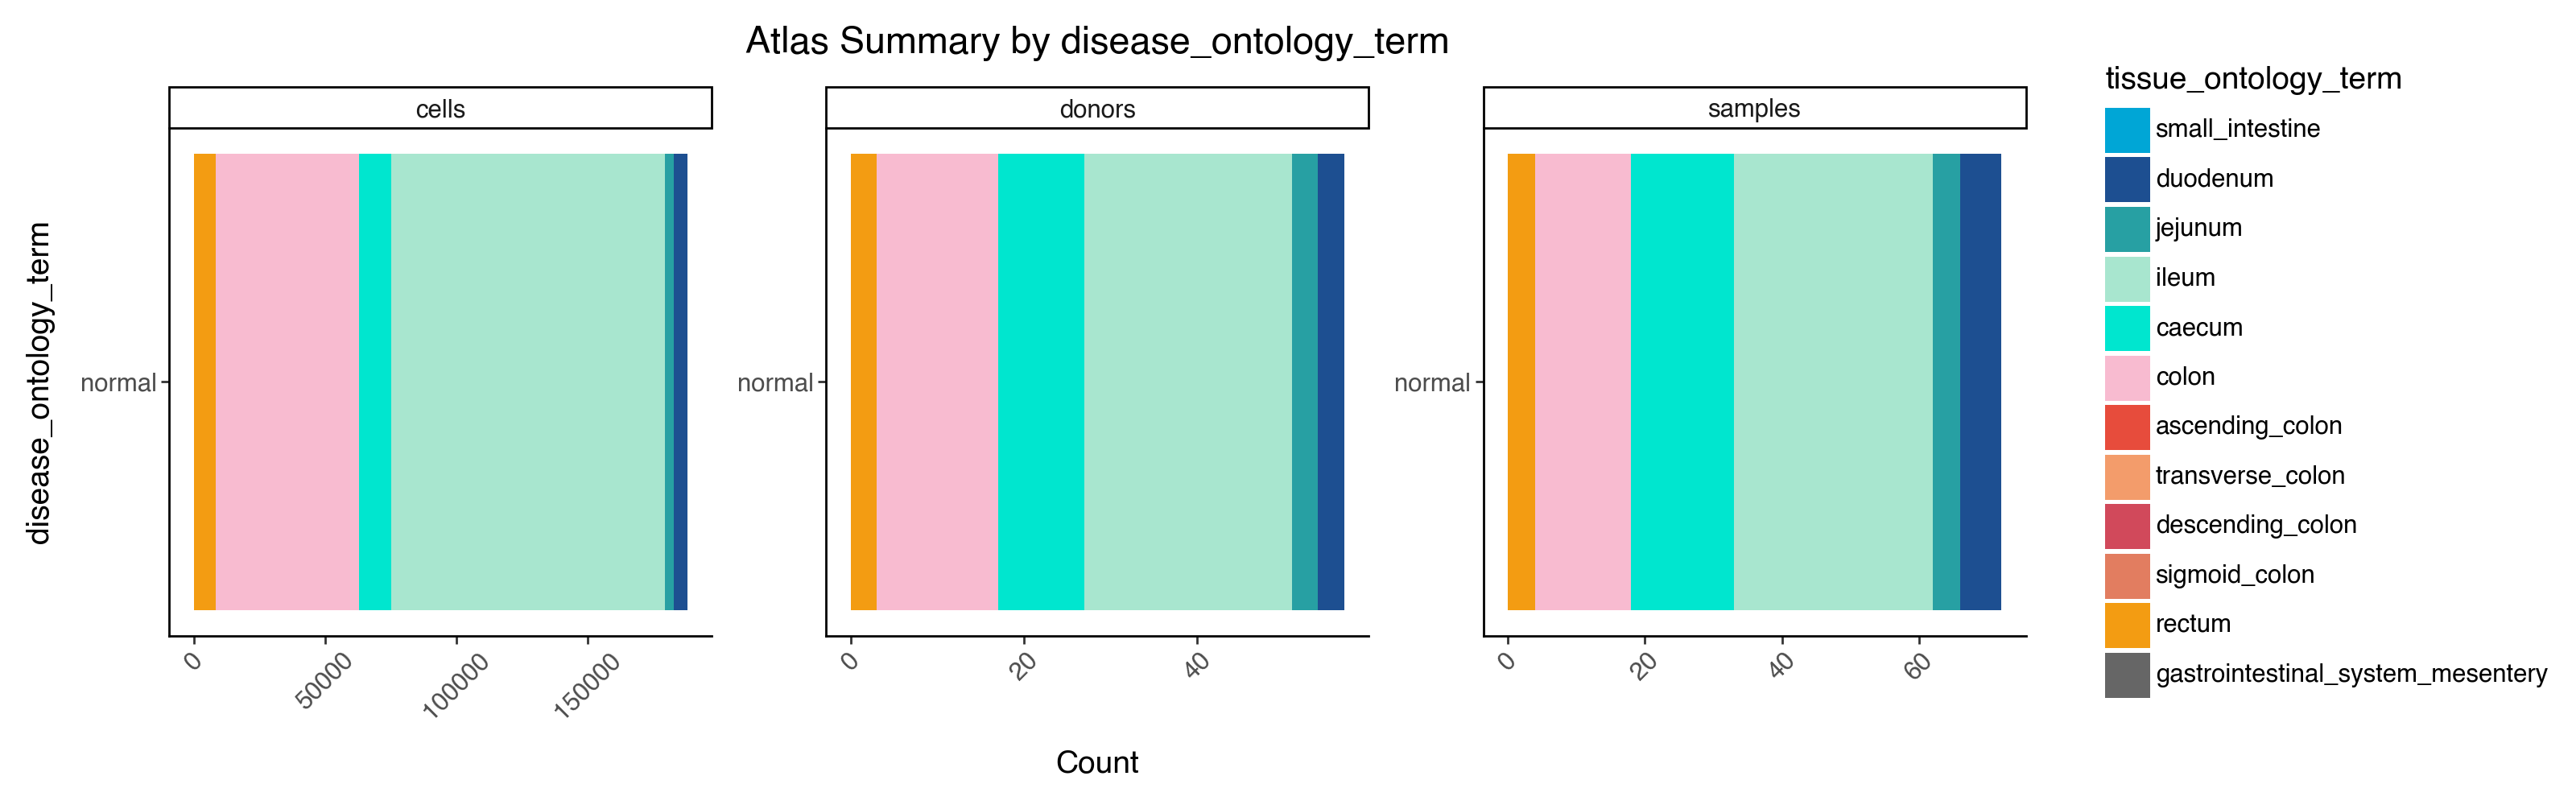

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_disease_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [54]:
# tissue_order = list(['small_intestine', 'duodenum', 'jejunum', 'ileum', 'caecum', 
#                 'colon', 'ascending_colon', 'transverse_colon', 'descending_colon', 'sigmoid_colon',
#                'rectum', 'gastrointestinal_system_mesentery'])

group = 'disease_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = pal,
                                stacking_var = 'tissue_ontology_term', 
                                stacking_values=tissue_order
                               )
wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


In [20]:
meta

,CellID,dataset_id,donor_id,sample_id,author_cell_type,tissue_ontology_term,tissue_ontology_term_id,tissue_free_text,sample_source,sample_collection_method,...,worksheet,closest_GCA_celltype,Lineage,Differentia,Habitus,Status,Whim,markers,neg_markers,cell_id
0,Dominguez2022_Pan_T7935490_AAACCTGCAAATTGCC,Dominguez2022,A29_390C,Pan_T7935490,Trm_Th1/Th17,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD4 Th1,Immune,Lymphoid,T Cells,CD4 T Cells,Th1,"CD4, TBX21, IFNG, TNF",NaN,0
1,Dominguez2022_Pan_T7935490_AAACGGGCATCTGGTA,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,1
2,Dominguez2022_Pan_T7935490_AAACGGGTCTTGCATT,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,2
3,Dominguez2022_Pan_T7935490_AAAGCAATCATCGCTC,Dominguez2022,A29_390C,Pan_T7935490,Trm_gut_CD8,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,CD8 TRM,Immune,Lymphoid,T Cells,CD8 T Cells,TRM (resident memory T cell),"CD8A, CD8B, ITGAE, CD69,ITGA1,RORA",NaN,3
4,Dominguez2022_Pan_T7935490_AAAGTAGCAGTCACTA,Dominguez2022,A29_390C,Pan_T7935490,Trm_Tgd,ileum,UBERON:0002116,NaN,organ_donor,surgical_resection,...,Dominguez2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381934,Drokhylansky2020_H4_S24.TTTGTCAGTCAGTGGA,Drokhylansky2020,H4,H4_S24,Myocyte_1,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381934
3381935,Drokhylansky2020_H4_S24.TTTGTCAGTTACAGAA,Drokhylansky2020,H4,H4_S24,Myocyte_1,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381935
3381936,Drokhylansky2020_H4_S24.TTTGTCAGTTAGAACA,Drokhylansky2020,H4,H4_S24,Glia_3,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,Glia,Stromal,Glia,NaN,NaN,NaN,"NRXN1, S100B, SOX10,CDH19, CRYAB, PLP1, SPP1, ...",NaN,3381936
3381937,Drokhylansky2020_H4_S24.TTTGTCATCCCTCTTT,Drokhylansky2020,H4,H4_S24,Myocyte_2,descending_colon,UBERON:0001158,Submucosa/Mucosa,surgical_donor,surgical_resection,...,Drokhylansky2020,SMC Inner Muscle Cells,Stromal,Smooth Muscle Cells (SMC),Inner Muscle Cells,NaN,NaN,"FOXF2, MORN5",NaN,3381937


In [55]:
def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Convert stacking variable to categorical with a specific order
    if stacking_var:
        df[stacking_var] = pd.Categorical(df[stacking_var], categories=stacking_values, ordered=True)
        
        # Compute summary statistics per group
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill=stacking_var))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5),
                axis_text_y=element_text(hjust=1),
                legend_position='right',
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))
            + scale_fill_manual(values=color_palette, limits=stacking_values, breaks=stacking_values)  # Directly use provided color palette
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p


In [56]:

color_palette = pal

grouping_var = 'alignment_software'

file_path = f"/Users/kylekimler/Projects/GCA/byTheNumbers/plots/tissue_{group}_summary.png"

summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

# Melt the DataFrame for easier plotting with facets
melted_df = summary_df.melt(id_vars=[grouping_var],
                            var_name='Category', value_name='Count')

melted_df = melted_df[melted_df.Category.isin(['cells'])].reset_index()

# Plot without stacking
p = (
    ggplot(melted_df, aes(x=grouping_var, y='Count'))
    + geom_bar(stat='identity', position='dodge', fill = pal[0])
    + coord_flip()
    + theme_classic(base_size=14)
    + theme(
        axis_text_x=element_text(rotation=45, hjust=0.5), 
        axis_text_y=element_text(hjust=1),  # Justify y-axis labels
        legend_position='right', 
        subplots_adjust={'right': 0.85},
        figure_size=(16, 8))  # Adjust figure size for long labels
    + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
)

    # Remove y-axis tick labels for the second and third facets
p = p + theme(
    strip_text_y=element_blank()
)

wid = 16
hi = 5
print(p + theme(figure_size=(wid, hi)))

plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


NameError: name 'df' is not defined